# ChIP Atlas CD4+ T cell TF data — exploratory analysis

Exploration of consensus ChIP-seq peaks and their overlap with gene promoters (TSS ± 2 kb, hg38 / GENCODE v48).

In [1]:
import glob
import os
import scanpy as sc
import anndata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sys
sys.path.append('../3_DE_analysis')
from DE_analysis_utils import *

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42


In [2]:
CHIP_DIR = "/mnt/oak/users/emma/data/ChIP_atlas_data"
RESULTS_DIR = "/mnt/oak/users/emma/bin/GWT_perturbseq_analysis/src/9_ChIP_analysis/results"
MANIFEST = "/mnt/oak/users/emma/bin/GWT_perturbseq_analysis/src/9_ChIP_analysis/chipatlas_cd4_tf_experiments.tsv"

## 1. Consensus peaks per TF

In [3]:
manifest = pd.read_csv(MANIFEST, sep="\t")
n_tracks = manifest.groupby("tf").size().rename("n_tracks")

# Count consensus peaks per TF
consensus_files = glob.glob(os.path.join(CHIP_DIR, "*", "*_consensus_peaks.bed"))
consensus_counts = {}
for f in consensus_files:
    tf = os.path.basename(os.path.dirname(f))
    consensus_counts[tf] = sum(1 for _ in open(f))

peak_df = (
    pd.DataFrame.from_dict(consensus_counts, orient="index", columns=["n_consensus_peaks"])
    .join(n_tracks)
    .sort_values("n_consensus_peaks", ascending=False)
).dropna()
peak_df

,n_consensus_peaks,n_tracks
FOSL2,6505,2.0
GATA3,4481,1.0
TRIM28,4442,4.0
BATF,2361,2.0
REST,1425,1.0
YY1,1102,1.0
PRKCQ,850,4.0
BCL6,768,2.0
CREBBP,495,1.0
INO80,443,1.0


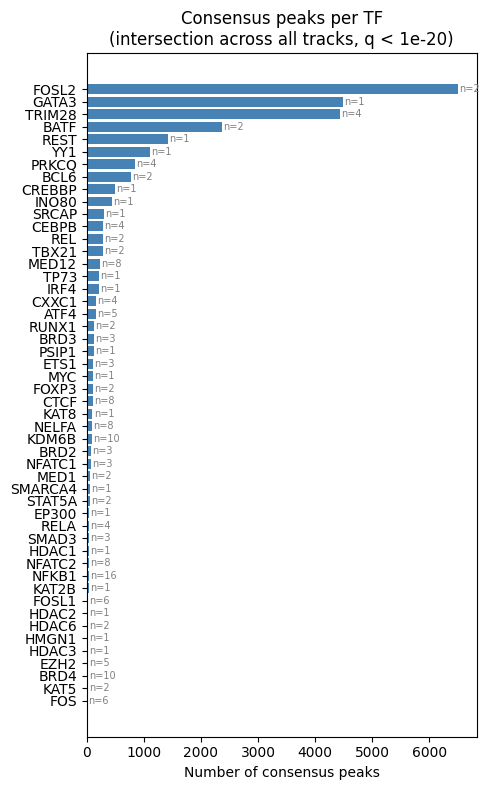

In [4]:
fig, ax = plt.subplots(figsize=(5, 8))
bars = ax.barh(peak_df.index, peak_df["n_consensus_peaks"], color="steelblue")
ax.set_xlabel("Number of consensus peaks")
ax.set_title("Consensus peaks per TF\n(intersection across all tracks, q < 1e-20)")
ax.invert_yaxis()

# Annotate with n_tracks
for bar, (_, row) in zip(bars, peak_df.iterrows()):
    ax.text(
        bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
        f"n={int(row['n_tracks'])}",
        va="center", fontsize=7, color="grey"
    )

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "consensus_peaks_per_tf.pdf"), bbox_inches="tight")
plt.show()

## 2. Promoter overlaps per TF

In [13]:
binary = pd.read_parquet(os.path.join(RESULTS_DIR, "tf_promoter_binary_matrix.parquet"))
binary = binary.groupby('gene_name').sum()

tf_cols = [c for c in binary.columns if c != "gene_name"]
n_genes = len(binary)

promoter_hits = binary[tf_cols].sum().rename("n_genes_with_peak").to_frame()
promoter_hits = promoter_hits.join(peak_df[["n_consensus_peaks", "n_tracks"]])
# % of all genes that have ≥1 consensus peak at their promoter
promoter_hits["pct_genes_with_peak"] = (
    promoter_hits["n_genes_with_peak"] / n_genes * 100
).round(2)
promoter_hits = promoter_hits.sort_values("n_genes_with_peak", ascending=False).dropna()
promoter_hits

,n_genes_with_peak,n_consensus_peaks,n_tracks,pct_genes_with_peak
FOSL2,1750,6505.0,2.0,2.27
YY1,1702,1102.0,1.0,2.21
GATA3,1344,4481.0,1.0,1.74
BCL6,784,768.0,2.0,1.02
REST,733,1425.0,1.0,0.95
CREBBP,501,495.0,1.0,0.65
BATF,446,2361.0,2.0,0.58
PRKCQ,193,850.0,4.0,0.25
MED12,182,222.0,8.0,0.24
ATF4,168,156.0,5.0,0.22


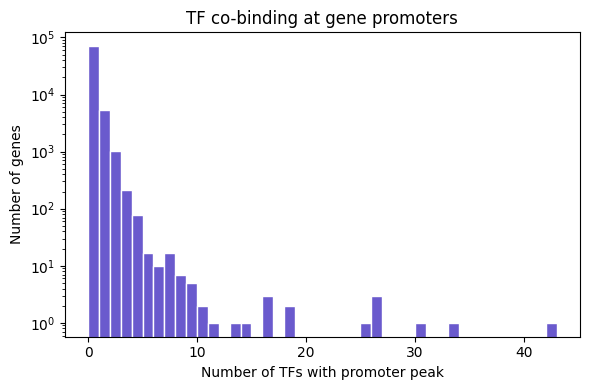

Genes with ≥1 TF peak at promoter: 6,819
Genes with 0 TF peaks: 70,254


In [14]:
# Number of TFs binding each gene's promoter
binary["n_tfs"] = binary[tf_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(binary["n_tfs"], bins=range(0, binary["n_tfs"].max() + 2), color="slateblue", edgecolor="white")
ax.set_xlabel("Number of TFs with promoter peak")
ax.set_ylabel("Number of genes")
ax.set_title("TF co-binding at gene promoters")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tf_cobinding_histogram.pdf"), bbox_inches="tight")
plt.show()

print(f"Genes with ≥1 TF peak at promoter: {(binary['n_tfs'] > 0).sum():,}")
print(f"Genes with 0 TF peaks: {(binary['n_tfs'] == 0).sum():,}")

## Load perturb-seq effects

In [15]:
OAKPATH = '/mnt/oak/'
datadir = f'{OAKPATH}/users/emma/data/GWT/CD4i_final/'
experiment_name = 'CD4i_final'
adata_de = sc.read_h5ad(datadir + f'/DE_results_all_confounders/{experiment_name}.merged_DE_results.h5ad')

adata_de.layers['zscore'] = adata_de.layers['log_fc'] / adata_de.layers['lfcSE']
adata_de.layers['zscore'][np.where(adata_de.layers['zscore'] > 100)] = 100
for cond in adata_de.obs.culture_condition.unique():
    affected_gs_cond = np.sum(adata_de[adata_de.obs['culture_condition'] == cond].layers['adj_p_value'] < 0.1, axis=0)
    adata_de.var[f'n_signif_effects_{cond}'] = affected_gs_cond

adata_de.var_names = adata_de.var['gene_name'].values

# Filter very lowly expressed genes
base_mean_df = sc.get.obs_df(adata_de, adata_de.var_names.tolist() + ['culture_condition', 'chunk'], layer='baseMean')
base_mean_df = base_mean_df.drop_duplicates().sort_values('culture_condition')

# Calculate for Rest condition
base_mean_rest = base_mean_df[base_mean_df['culture_condition'] == 'Rest'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Rest'] = base_mean_rest.mean(1).fillna(0)
adata_de.var['std_baseMean_Rest'] = base_mean_rest.std(1).fillna(10000)

# Calculate for Stim8hr condition
base_mean_stim8 = base_mean_df[base_mean_df['culture_condition'] == 'Stim8hr'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Stim8hr'] = base_mean_stim8.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim8hr'] = base_mean_stim8.std(1).fillna(10000)

# Calculate for Stim48hr condition
base_mean_stim48 = base_mean_df[base_mean_df['culture_condition'] == 'Stim48hr'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Stim48hr'] = base_mean_stim48.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim48hr'] = base_mean_stim48.std(1).fillna(10000)

# Exclude from analysis genes with very low base mean (messing up reliability estimate)
gs_mask = (adata_de.var['mean_baseMean_Rest'] > 0.1) & (adata_de.var['mean_baseMean_Stim8hr'] > 0.1) & (adata_de.var['mean_baseMean_Stim48hr'] > 0.1)
adata_de = adata_de[:, gs_mask].copy()
sum(~gs_mask)

3677

In [16]:
adata_de_corr = anndata.experimental.read_lazy(datadir + f'/DE_results_all_confounders/CD4i_final.merged_DE_results_corrected.h5ad')
target_contrast_correction_dict = dict(zip(adata_de_corr.obs.to_dataframe()['target_contrast'], adata_de_corr.obs.to_dataframe()['target_contrast_corrected']))
target_contrast_name_correction_dict = dict(zip(adata_de_corr.obs.to_dataframe()['target_contrast_gene_name'], adata_de_corr.obs.to_dataframe()['target_contrast_gene_name_corrected']))

adata_de.obs['target_contrast_gene_name'] = adata_de.obs['target_contrast_gene_name'].map(target_contrast_name_correction_dict)
adata_de.obs['target_contrast'] = adata_de.obs['target_contrast'].map(target_contrast_correction_dict)

# remove missing perturb
adata_de = adata_de[~adata_de.obs['target_contrast_gene_name'].isna()].copy()

# Load summary stats
DE_stats = pd.read_csv(datadir + f'/DE_results_all_confounders/DE_summary_stats_per_target_corrected.csv', index_col=0)

In [17]:
adata_de

AnnData object with n_obs × n_vars = 33983 × 10282
    obs: 'target_contrast_gene_name', 'culture_condition', 'target_contrast', 'chunk', 'n_cells_target'
    var: 'gene_ids', 'gene_name', 'n_signif_effects_Stim8hr', 'n_signif_effects_Stim48hr', 'n_signif_effects_Rest', 'mean_baseMean_Rest', 'std_baseMean_Rest', 'mean_baseMean_Stim8hr', 'std_baseMean_Stim8hr', 'mean_baseMean_Stim48hr', 'std_baseMean_Stim48hr'
    layers: 'adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore'

## Direct vs indirect effects

1. Is the mean absolute zscore or DE effect higher at genes with peaks compared to other genes?
2. If we take genes downstream genes of KDs of 'direct effect' genes, are these more likely to be affected by the upstream regulator than other genes?

In [18]:
tot_de_genes = DE_stats[DE_stats['target_name'].isin(tf_cols)].pivot(index='target_name', columns='condition', values='n_total_de_genes').sum(axis=1)
keep_tfs = tot_de_genes[tot_de_genes >= 30].index.tolist() # remove when very little downstream genes are detected across conditions
tf_2_gs_effects = get_DE_results_long(adata_de, targets=keep_tfs)

In [19]:
tf_2_gs_effects.head()

,index,gene,log_fc,zscore,adj_p_value,significant,gene_name,culture_condition,target_contrast,target_contrast_gene_name
0,ENSG00000005339_Rest,AAAS,-0.141387,-1.666614,0.298751,False,AAAS,Rest,ENSG00000005339,CREBBP
1,ENSG00000005339_Rest,AACS,0.491070,3.328396,0.015084,True,AACS,Rest,ENSG00000005339,CREBBP
2,ENSG00000005339_Rest,AAGAB,-0.086345,-1.553313,0.341320,False,AAGAB,Rest,ENSG00000005339,CREBBP
3,ENSG00000005339_Rest,AAK1,-0.008292,-0.159196,0.944343,False,AAK1,Rest,ENSG00000005339,CREBBP
4,ENSG00000005339_Rest,AAMDC,0.461400,3.788008,0.004548,True,AAMDC,Rest,ENSG00000005339,CREBBP


In [20]:
from scipy.stats import fisher_exact

# Get assignment of peaks for each target
binary_long = binary.reset_index().melt(id_vars='gene_name', var_name='target_contrast_gene_name', value_name='has_peak')
binary_long = binary_long[binary_long.gene_name.isin(tf_2_gs_effects.gene_name)].copy()

tf_2_gs_effects = pd.merge(tf_2_gs_effects, binary_long, how='left')

def odds_ci(a, b, c, d):
    """95% CI for odds ratio using Woolf log method with Haldane-Anscombe correction."""
    if 0 in [a, b, c, d]:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    or_est = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return np.exp(np.log(or_est) - 1.96*se), np.exp(np.log(or_est) + 1.96*se)

# Get all culture conditions present
culture_conditions = tf_2_gs_effects["culture_condition"].dropna().unique()

# Store results for each condition in a dictionary of DataFrames
odds_results_by_condition = {}

for condition in culture_conditions:
    tf_2_gs_effects_cond = tf_2_gs_effects[tf_2_gs_effects["culture_condition"] == condition].copy()

    # For each (target, gene), check significance specifically in this condition
    sig_condition = (
        tf_2_gs_effects_cond
        .groupby(['target_contrast_gene_name', 'gene_name'])
        .agg(significant_any=('significant', 'any'), has_peak=('has_peak', 'first'))
        .reset_index()
    )
    
    odds_results = []
    for target, group in sig_condition.groupby('target_contrast_gene_name'):
        ct = pd.crosstab(group['has_peak'], group['significant_any'])

        sig_with_peak     = ct.loc[1.0, True]  if (1.0 in ct.index) and (True  in ct.columns) else 0
        non_sig_with_peak = ct.loc[1.0, False] if (1.0 in ct.index) and (False in ct.columns) else 0
        sig_without_peak  = ct.loc[0.0, True]  if (0.0 in ct.index) and (True  in ct.columns) else 0
        non_sig_without_peak = ct.loc[0.0, False] if (0.0 in ct.index) and (False in ct.columns) else 0

        contingency = np.array([
            [sig_with_peak,    non_sig_with_peak],
            [sig_without_peak, non_sig_without_peak]
        ])
        odds_ratio, pvalue = fisher_exact(contingency, alternative='two-sided')
        ci_lower, ci_upper = odds_ci(sig_with_peak, non_sig_with_peak, sig_without_peak, non_sig_without_peak)

        odds_results.append({
            'target': target,
            'culture_condition': condition,
            'sig_with_peak': sig_with_peak,
            'non_sig_with_peak': non_sig_with_peak,
            'sig_without_peak': sig_without_peak,
            'non_sig_without_peak': non_sig_without_peak,
            'odds_ratio': odds_ratio,
            'pvalue': pvalue,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        })

    odds_results_df = pd.DataFrame(odds_results)
    odds_results_by_condition[condition] = odds_results_df

# Concatenate all results into single DataFrame (optional)
odds_results_all_conditions = pd.concat(odds_results_by_condition.values(), ignore_index=True)
odds_results_all_conditions.head()

,target,culture_condition,sig_with_peak,non_sig_with_peak,sig_without_peak,non_sig_without_peak,odds_ratio,pvalue,ci_lower,ci_upper
0,ATF4,Rest,3,76,83,10093,4.800095,0.028522,1.484179,15.524351
1,BATF,Rest,3,95,373,9784,0.828334,1.000000,0.261240,2.626462
2,BCL6,Rest,1,376,15,9863,1.748759,0.451041,0.230388,13.273954
3,CREBBP,Rest,24,165,1534,8532,0.809008,0.412548,0.525410,1.245681
4,CXXC1,Rest,1,10,531,9713,1.829190,0.443605,0.233716,14.316228


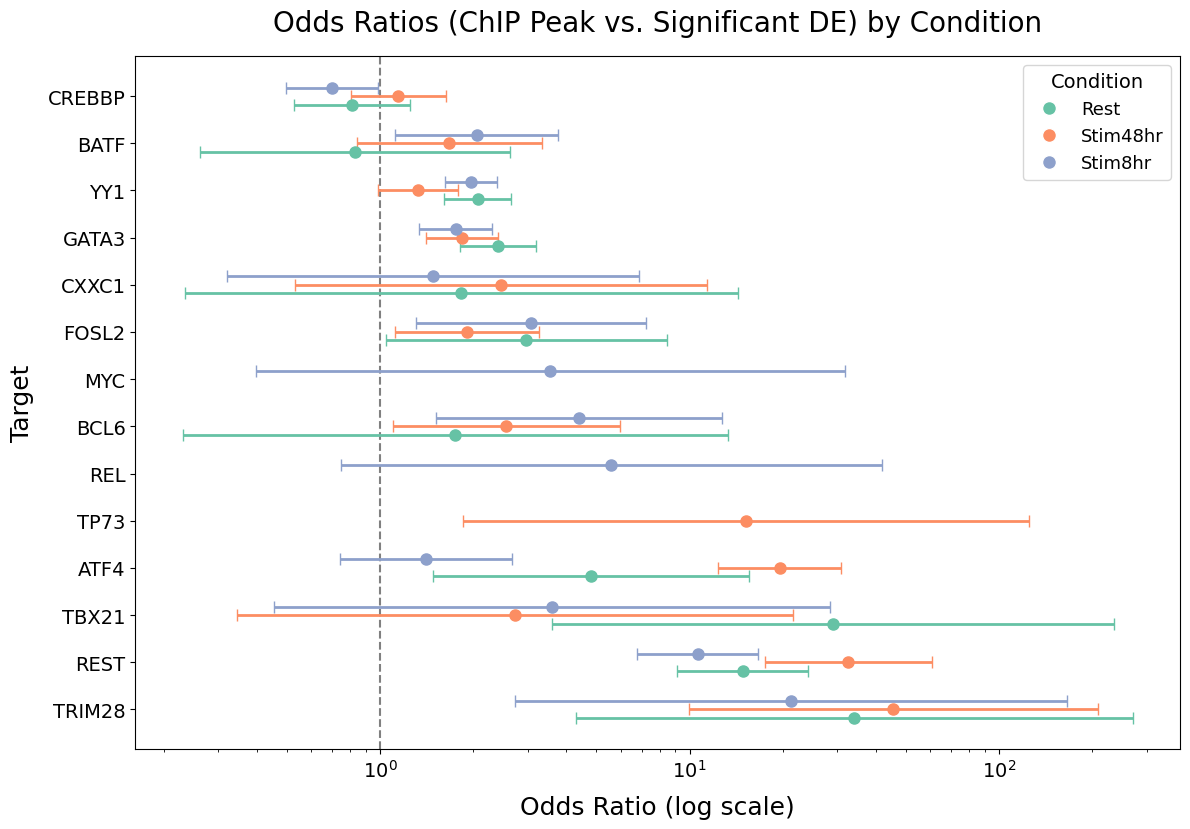

In [21]:
import seaborn as sns

# Prepare the data: filter out odds_ratio == 0, drop NA, sort as before
plot_df = odds_results_all_conditions[odds_results_all_conditions.odds_ratio != 0].dropna()

# Keep only targets that have odds_ratio > 1 in at least one condition
targets_with_updated_or = plot_df.groupby("target")["odds_ratio"].max()
targets_to_plot = targets_with_updated_or[targets_with_updated_or > 1].index
plot_df = plot_df[plot_df["target"].isin(targets_to_plot)].copy()

# Calculate error bars
plot_df["err_low"] = plot_df["odds_ratio"] - plot_df["ci_lower"]
plot_df["err_high"] = plot_df["ci_upper"] - plot_df["odds_ratio"]
plot_df["err_low"] = plot_df["err_low"].clip(lower=0)
plot_df["err_high"] = plot_df["err_high"].clip(lower=0)

# Sort targets for y-axis (so ordering stays consistent)
ordered_targets = (
    plot_df.groupby("target")["odds_ratio"]
    .max()
    .sort_values(ascending=False)
    .index
)
plot_df["target"] = pd.Categorical(plot_df["target"], categories=ordered_targets, ordered=True)

# Set categorical type for 'culture_condition' for nice color mapping
conditions_order = plot_df["culture_condition"].unique()
plot_df["culture_condition"] = pd.Categorical(plot_df["culture_condition"], categories=conditions_order, ordered=True)

# Plot with seaborn - pointplot with error bars, hue by culture_condition
plt.figure(figsize=(12, 0.6 * len(ordered_targets)))
ax = plt.gca()

# Plot each point with error bars for each condition
for i, row in plot_df.iterrows():
    # y position depends on target, and offset by condition for visibility
    y_base = list(ordered_targets).index(row["target"])
    # Slight offset for each condition to avoid overlap (depends on total conditions)
    n_cond = len(conditions_order)
    cond_idx = list(conditions_order).index(row["culture_condition"])
    offset = (cond_idx - (n_cond - 1) / 2) * 0.18  # adjust this value for clarity
    y = y_base + offset
    ax.errorbar(
        row["odds_ratio"], y,
        xerr=[[row["err_low"]], [row["err_high"]]],
        fmt="o",
        color=sns.color_palette("Set2", n_colors=n_cond)[cond_idx],
        label=row["culture_condition"] if (y_base == 0) else "",
        capsize=4,
        markersize=8,
        elinewidth=2.0,
        linestyle="none",
        zorder=2
    )

# Add legend only once per condition
handles = []
labels = []
for cond_idx, condition in enumerate(conditions_order):
    handles.append(
        plt.Line2D([0], [0], marker="o", color="w", label=condition,
                   markerfacecolor=sns.color_palette("Set2", n_colors=len(conditions_order))[cond_idx], markersize=10)
    )
    labels.append(condition)
ax.legend(handles, labels, title="Condition", loc="upper right", fontsize=13, title_fontsize=14)

plt.axvline(1, color="grey", linestyle="--", linewidth=1.5, zorder=1)
plt.xlabel("Odds Ratio (log scale)", fontsize=18, labelpad=10)
plt.xscale("log")
plt.ylabel("Target", fontsize=18, labelpad=10)
plt.yticks(ticks=range(len(ordered_targets)), labels=ordered_targets, fontsize=14)
plt.xticks(fontsize=14)
plt.title(
    "Odds Ratios (ChIP Peak vs. Significant DE) by Condition",
    fontsize=20, pad=18
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "odds_ratio_forest_plot_by_condition.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(RESULTS_DIR, "odds_ratio_forest_plot_by_condition.png"), bbox_inches="tight", dpi=150)
plt.show()

In [22]:
from scipy.stats import fisher_exact

# Get assignment of peaks for each target
binary_long = binary.reset_index().melt(id_vars='gene_name', var_name='target_contrast_gene_name', value_name='has_peak')
binary_long = binary_long[binary_long.gene_name.isin(tf_2_gs_effects.gene_name)].copy()

tf_2_gs_effects = pd.merge(tf_2_gs_effects, binary_long, how='left')

# For each (target, gene), determine if significant in at least one condition
sig_any = (
    tf_2_gs_effects
    .groupby(['target_contrast_gene_name', 'gene_name'])
    .agg(significant_any=('significant', 'any'), has_peak=('has_peak', 'first'))
    .reset_index()
)

def odds_ci(a, b, c, d):
    """95% CI for odds ratio using Woolf log method with Haldane-Anscombe correction."""
    if 0 in [a, b, c, d]:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    or_est = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return np.exp(np.log(or_est) - 1.96*se), np.exp(np.log(or_est) + 1.96*se)

odds_results = []
for target, group in sig_any.groupby('target_contrast_gene_name'):
    ct = pd.crosstab(group['has_peak'], group['significant_any'])

    sig_with_peak     = ct.loc[1.0, True]  if (1.0 in ct.index) and (True  in ct.columns) else 0
    non_sig_with_peak = ct.loc[1.0, False] if (1.0 in ct.index) and (False in ct.columns) else 0
    sig_without_peak  = ct.loc[0.0, True]  if (0.0 in ct.index) and (True  in ct.columns) else 0
    non_sig_without_peak = ct.loc[0.0, False] if (0.0 in ct.index) and (False in ct.columns) else 0

    contingency = np.array([
        [sig_with_peak,    non_sig_with_peak],
        [sig_without_peak, non_sig_without_peak]
    ])
    odds_ratio, pvalue = fisher_exact(contingency, alternative='two-sided')
    ci_lower, ci_upper = odds_ci(sig_with_peak, non_sig_with_peak, sig_without_peak, non_sig_without_peak)

    odds_results.append({
        'target': target,
        'sig_with_peak': sig_with_peak,
        'non_sig_with_peak': non_sig_with_peak,
        'sig_without_peak': sig_without_peak,
        'non_sig_without_peak': non_sig_without_peak,
        'odds_ratio': odds_ratio,
        'pvalue': pvalue,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
    })

odds_results_df = pd.DataFrame(odds_results)
odds_results_df.head()

,target,sig_with_peak,non_sig_with_peak,sig_without_peak,non_sig_without_peak,odds_ratio,pvalue,ci_lower,ci_upper
0,ATF4,35,44,1384,8792,5.053205,3.942527e-11,3.230039,7.905441
1,BATF,21,77,1321,8836,1.824238,2.244433e-02,1.122089,2.965758
2,BCL6,8,369,80,9798,2.655285,1.540345e-02,1.274266,5.533019
3,CREBBP,78,111,4560,5506,0.848483,3.017924e-01,0.633472,1.136471
4,CXXC1,4,7,2191,8053,2.100280,2.640427e-01,0.614263,7.181249


In [23]:
odds_results_df

,target,sig_with_peak,non_sig_with_peak,sig_without_peak,non_sig_without_peak,odds_ratio,pvalue,ci_lower,ci_upper
0,ATF4,35,44,1384,8792,5.053205,3.942527e-11,3.230039,7.905441
1,BATF,21,77,1321,8836,1.824238,2.244433e-02,1.122089,2.965758
2,BCL6,8,369,80,9798,2.655285,1.540345e-02,1.274266,5.533019
3,CREBBP,78,111,4560,5506,0.848483,3.017924e-01,0.633472,1.136471
4,CXXC1,4,7,2191,8053,2.100280,2.640427e-01,0.614263,7.181249
5,EP300,0,0,373,9882,NaN,1.000000e+00,0.524265,1335.370488
6,EZH2,0,0,750,9505,NaN,1.000000e+00,0.251122,638.799472
7,FOS,0,0,39,10216,NaN,1.000000e+00,5.068401,13198.942274
8,FOSL2,21,409,236,9589,2.086207,3.791574e-03,1.320720,3.295367
9,GATA3,128,224,2419,7484,1.767909,1.138446e-06,1.416009,2.207260


In [24]:
# import seaborn as sns

# # Compute total number of promoter peaks per target (sum across conditions)
# total_peaks_df = odds_results_df.groupby("target")[["sig_with_peak", "non_sig_with_peak"]].max().sum(axis=1)
# total_peaks_df = total_peaks_df.sort_values(ascending=False).reset_index()
# total_peaks_df.columns = ['target', 'total_peaks']

# # Preserve this order for barplotting
# sorted_targets = total_peaks_df["target"].tolist()

# # Subplot 1: Barplot of number of promoter peaks per target (sorted)
# fig, axes = plt.subplots(1, 2, figsize=(10, 0.2 * len(sorted_targets) + 1), sharey=True)

# ax = axes[0]
# sns.barplot(
#     y="target", x="total_peaks", data=total_peaks_df,
#     order=sorted_targets, color="grey", ax=ax
# )
# ax.set_xlabel("Number of genes with peaks at promoter")
# ax.set_ylabel("")
# ax.set_title("Number of promoter peaks per target")
# ax.invert_yaxis()

# # Subplot 2: Barplot of number of significant DE genes per target/condition, hue by condition
# # Prepare data: sum significant genes with peak and without peak, by target/condition
# sig_genes_df = odds_results_df.copy()
# sig_genes_df["total_sig_genes"] = sig_genes_df["sig_with_peak"] + sig_genes_df["sig_without_peak"]
# # To keep targets sorted in the same order:
# sig_genes_df["target"] = pd.Categorical(sig_genes_df["target"], categories=sorted_targets, ordered=True)
# sig_genes_df = sig_genes_df.sort_values(["target", "condition"])

# ax = axes[1]
# sns.barplot(
#     y="target", x="total_sig_genes", hue="condition",
#     data=sig_genes_df, order=sorted_targets, ax=ax
# )
# ax.set_xlabel("Number of significant DE genes")
# ax.set_ylabel("")
# ax.set_title("Significant DE genes by condition")
# ax.legend(title="Condition", fontsize=8, title_fontsize=9)
# ax.invert_yaxis()

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "peaks_sig_barplots.pdf"), bbox_inches="tight")
# plt.show()


<Figure size 500x280 with 0 Axes>

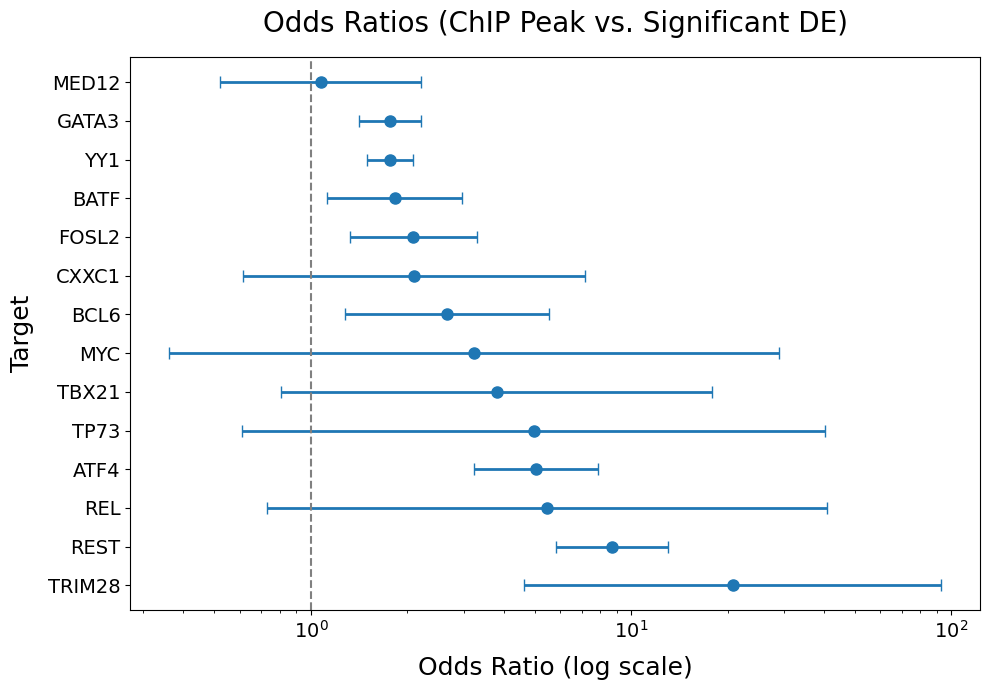

In [25]:
try:
    odds_results_df
except:
    odds_results_df = pd.read_csv(os.path.join(RESULTS_DIR, "odds_ratio_results.csv"))

# Prepare the data: filter out odds_ratio == 0, drop NA, sort as before
plot_df = odds_results_df[odds_results_df.odds_ratio != 0].dropna()

# Keep only targets that have odds_ratio > 1 in at least one condition
targets_with_updated_or = plot_df.groupby("target")["odds_ratio"].max()
targets_to_plot = targets_with_updated_or[targets_with_updated_or > 1].index
plot_df = plot_df[plot_df["target"].isin(targets_to_plot)]

plot_df = plot_df.sort_values(["target", "odds_ratio"], ascending=[True, False]).reset_index(drop=True)

# Create figure
plt.figure(figsize=(5, 0.2 * len(plot_df["target"].unique())))

# Calculate error bars
plot_df["err_low"] = plot_df["odds_ratio"] - plot_df["ci_lower"]
plot_df["err_high"] = plot_df["ci_upper"] - plot_df["odds_ratio"]

# To allow log scale, avoid zeros and ensure errors are positive
plot_df["err_low"] = plot_df["err_low"].clip(lower=0)
plot_df["err_high"] = plot_df["err_high"].clip(lower=0)

# Sort targets for y-axis
ordered_targets = plot_df.sort_values("odds_ratio", ascending=False)["target"].unique()
target_to_idx = {t: i for i, t in enumerate(ordered_targets)}

# For each target, take (by default) the max odds_ratio (or you could aggregate in a different way)
agg_plot_df = (
    plot_df.sort_values("odds_ratio", ascending=False)
    .drop_duplicates(subset="target")
    .set_index("target")
    .reindex(ordered_targets)
    .reset_index()
)

# Prepare error bars
agg_plot_df["err_low"] = agg_plot_df["odds_ratio"] - agg_plot_df["ci_lower"]
agg_plot_df["err_high"] = agg_plot_df["ci_upper"] - agg_plot_df["odds_ratio"]
agg_plot_df["err_low"] = agg_plot_df["err_low"].clip(lower=0)
agg_plot_df["err_high"] = agg_plot_df["err_high"].clip(lower=0)

# Plot
plt.figure(figsize=(10, 0.5 * len(ordered_targets)))
y_values = range(len(ordered_targets))
plt.errorbar(
    x=agg_plot_df["odds_ratio"],
    y=y_values,
    xerr=[agg_plot_df["err_low"], agg_plot_df["err_high"]],
    fmt="o",
    capsize=4,
    markersize=8,      # larger marker size
    elinewidth=2.0,    # thicker error lines
    linestyle="none"
)

plt.axvline(1, color="grey", linestyle="--", linewidth=1.5)
plt.xlabel("Odds Ratio (log scale)", fontsize=18, labelpad=10)
plt.xscale("log")
plt.ylabel("Target", fontsize=18, labelpad=10)
plt.yticks(ticks=y_values, labels=ordered_targets, fontsize=14)
plt.xticks(fontsize=14)
plt.title(
    "Odds Ratios (ChIP Peak vs. Significant DE)",
    fontsize=20, pad=18
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "odds_ratio_forest_plot.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(RESULTS_DIR, "odds_ratio_forest_plot.png"), bbox_inches="tight", dpi=150)
plt.show()

In [21]:
tf_2_gs_effects.to_csv("results/tf2gene_DE_effects.csv")

In [26]:
tf_2_gs_effects = pd.read_csv("results/tf2gene_DE_effects.csv")

## Predict total effect from direct edges

### Filter to significant target-condition pairs from odds ratio analysis

In [29]:
from statsmodels.stats.multitest import multipletests

# Select targets with:
#   (a) >= 3 significant genes with a peak (enough direct hits to compute predicted effects), OR
#   (b) significant enrichment of DE genes at peaks (OR > 1, p < 0.05)
sig_targets = odds_results_df[
    (odds_results_df['sig_with_peak'] >= 2) |
    ((odds_results_df['pvalue'] < 0.05) & (odds_results_df['odds_ratio'] > 1))
]['target'].tolist()

print(f"Targets selected: {len(sig_targets)}")
sig_targets

Targets selected: 12


['ATF4',
 'BATF',
 'BCL6',
 'CREBBP',
 'CXXC1',
 'FOSL2',
 'GATA3',
 'MED12',
 'REST',
 'TBX21',
 'TRIM28',
 'YY1']

In [32]:
from sklearn.linear_model import LinearRegression

def _mask_nonsignificant(effects_long, effects_pivot, c, effect_col, threshold):
    """Zero out entries in effects_pivot where adj_p_value >= threshold."""
    sig_pivot = (
        effects_long[effects_long['culture_condition'] == c]
        .pivot(index='gene_name', columns='target_contrast_gene_name', values='adj_p_value')
    )
    sig_pivot = sig_pivot.reindex(index=effects_pivot.index, columns=effects_pivot.columns)
    effects_pivot = effects_pivot.copy()
    effects_pivot[sig_pivot >= threshold] = 0.0
    return effects_pivot

def get_predicted_vs_true_effects(
    tf_2_gs_effects, adata_de, c, tf, n_negctrl=None, rng=None, effect_col="log_fc",
    only_significant_indirect=False, indirect_significance_threshold=0.1
):
    """
    For the given culture condition c and target tf, compute:
      - predicted_effect: predicted indirect effect from significant direct hits (with peak),
          weighted by the negative of each direct hit's observed effect (specified by effect_col)
      - lm_predicted_effect: same indirect effect matrix, but weights are fitted by a
          linear regression of indirect_effects -> true_effect
      - negctrl_predicted_effect: predicted indirect effect from non-significant direct hits
          (with peak, negative control), weighted by their observed effect (effect_col)
      - lm_negctrl_predicted_effect: same negctrl indirect effect matrix, but weights are
          fitted by a linear regression of indirect_effects_nc -> true_effect
      - true_effect: observed effect (effect_col) for all genes for this target and condition

    Parameters:
      - only_significant_indirect: if True, indirect effects are set to 0 for gene–target
          pairs where adj_p_value >= indirect_significance_threshold (default False)
      - indirect_significance_threshold: adj_p_value cutoff used when
          only_significant_indirect=True (default 0.1)

    Returns:
      - df: pd.DataFrame with columns
          ['predicted_effect', 'lm_predicted_effect', 'negctrl_predicted_effect',
           'lm_negctrl_predicted_effect', 'true_effect'], indexed by gene_name
      - direct_hits_df: pd.DataFrame indexed by direct-hit gene name with columns:
          'direct_effect'  – observed effect of TF on that gene (effect_col)
          'lm_coef'        – linear regression weight used for lm_predicted_effect
                             (NaN if LM was not fitted)
    """
    rng = np.random.default_rng() if rng is None else rng

    # Subset data for this target and condition
    onetarget = tf_2_gs_effects[
        (tf_2_gs_effects.target_contrast_gene_name == tf) & 
        (tf_2_gs_effects.culture_condition == c)
    ].drop_duplicates()

    # Putative direct hits: sig & has_peak & not self
    putative_direct_hits = onetarget[
        (onetarget['gene_name'] != tf) &
        (onetarget['significant']) &
        (onetarget['has_peak'] == 1)
    ].gene_name.unique().tolist()
    putative_direct_effect = onetarget[
        (onetarget['gene_name'] != tf) &
        (onetarget['significant']) &
        (onetarget['has_peak'] == 1)
    ].set_index('gene_name')[effect_col]

    # Build direct_hits_df: one row per direct hit, with direct effect and lm coefficient
    direct_hits_df = putative_direct_effect.rename("direct_effect").to_frame()
    direct_hits_df["lm_coef"] = np.nan

    # Compute indirect effects matrix (n_genes × n_direct_hits)
    indirect_effects_long = get_DE_results_long(adata_de, targets=putative_direct_hits)
    indirect_effects_long = indirect_effects_long[indirect_effects_long['culture_condition'] == c]
    indirect_effects = indirect_effects_long.pivot(index='gene_name', columns='target_contrast_gene_name', values=effect_col)

    if only_significant_indirect and len(putative_direct_hits) > 0:
        indirect_effects = _mask_nonsignificant(
            indirect_effects_long, indirect_effects, c, effect_col, indirect_significance_threshold
        )

    # True effect for this tf/condition
    true_effect = onetarget.set_index('gene_name')[effect_col]

    if len(putative_direct_hits) > 0:
        indirect_effects = indirect_effects.drop(putative_direct_hits, errors='ignore')

        # --- Prediction 1: weights = -direct_effect (sign/magnitude of each direct hit) ---
        predicted_effect = (indirect_effects * -putative_direct_effect.loc[indirect_effects.columns]).sum(1)

        # --- Prediction 2: weights fitted by linear regression on true_effect ---
        common_genes = indirect_effects.index.intersection(true_effect.index)
        X = indirect_effects.loc[common_genes].fillna(0).values
        y = true_effect.loc[common_genes].values
        if len(common_genes) > len(putative_direct_hits):
            lm = LinearRegression(fit_intercept=False)
            lm.fit(X, y)
            lm_predicted_effect = pd.Series(
                indirect_effects.fillna(0).values @ lm.coef_,
                index=indirect_effects.index
            )
            direct_hits_df.loc[indirect_effects.columns, "lm_coef"] = lm.coef_
        else:
            lm_predicted_effect = pd.Series(dtype=float)
    else:
        predicted_effect = pd.Series(dtype=float)
        lm_predicted_effect = pd.Series(dtype=float)

    # Negative control: non-sig genes with peak, not self
    negctrl_direct_hits_src = onetarget[
        (onetarget['gene_name'] != tf) &
        (~onetarget['significant']) &
        (onetarget['has_peak'] == 1)
    ].gene_name.unique().tolist()

    if n_negctrl is None:
        n_negctrl = len(putative_direct_hits)
    if len(negctrl_direct_hits_src) >= n_negctrl and n_negctrl > 0:
        negctrl_direct_hits = rng.choice(negctrl_direct_hits_src, size=n_negctrl, replace=False)
    else:
        negctrl_direct_hits = negctrl_direct_hits_src

    negctrl_direct_effect = onetarget[
        onetarget['gene_name'].isin(negctrl_direct_hits)
    ].set_index('gene_name')[effect_col]
    indirect_effects_nc_long = get_DE_results_long(adata_de, targets=negctrl_direct_hits)
    indirect_effects_nc_long = indirect_effects_nc_long[indirect_effects_nc_long['culture_condition'] == c]
    indirect_effects_nc = indirect_effects_nc_long.pivot(index='gene_name', columns='target_contrast_gene_name', values=effect_col)

    if only_significant_indirect and len(negctrl_direct_hits) > 0:
        indirect_effects_nc = _mask_nonsignificant(
            indirect_effects_nc_long, indirect_effects_nc, c, effect_col, indirect_significance_threshold
        )

    if len(negctrl_direct_hits) > 0:
        indirect_effects_nc = indirect_effects_nc.drop(negctrl_direct_hits, errors='ignore')
        negctrl_predicted_effect = (indirect_effects_nc * -negctrl_direct_effect.reindex(indirect_effects_nc.columns)).sum(1)

        # --- Prediction 4: negctrl weights fitted by linear regression on true_effect ---
        common_genes_nc = indirect_effects_nc.index.intersection(true_effect.index)
        X_nc = indirect_effects_nc.loc[common_genes_nc].fillna(0).values
        y_nc = true_effect.loc[common_genes_nc].values
        if len(common_genes_nc) > len(negctrl_direct_hits):
            lm_nc = LinearRegression(fit_intercept=False)
            lm_nc.fit(X_nc, y_nc)
            lm_negctrl_predicted_effect = pd.Series(
                indirect_effects_nc.fillna(0).values @ lm_nc.coef_,
                index=indirect_effects_nc.index
            )
        else:
            lm_negctrl_predicted_effect = pd.Series(dtype=float)
    else:
        negctrl_predicted_effect = pd.Series(dtype=float)
        lm_negctrl_predicted_effect = pd.Series(dtype=float)

    all_genes = set(true_effect.index)
    all_genes = (all_genes.union(predicted_effect.index).union(lm_predicted_effect.index)
                 .union(negctrl_predicted_effect.index).union(lm_negctrl_predicted_effect.index))
    df = pd.DataFrame({
        'predicted_effect': pd.Series(predicted_effect),
        'lm_predicted_effect': pd.Series(lm_predicted_effect),
        'negctrl_predicted_effect': pd.Series(negctrl_predicted_effect),
        'lm_negctrl_predicted_effect': pd.Series(lm_negctrl_predicted_effect),
        'true_effect': pd.Series(true_effect),
    })
    df = df.loc[df.index.isin(all_genes)]
    return df, direct_hits_df

# Example usage:
df_effects, direct_hits_df = get_predicted_vs_true_effects(tf_2_gs_effects, adata_de, c='Rest', tf='FOSL2')


In [33]:
df_effects['direct_hit'] = df_effects.index.isin(direct_hits_df.index)
df = df_effects[(~df_effects['direct_hit']) ]  # consider only trans-effects
df = df.drop('TRDC')
pl_direct = df.dropna(subset=['true_effect', 'predicted_effect'])

scipy.stats.pearsonr(pl_direct['true_effect'], pl_direct['predicted_effect'])

PearsonRResult(statistic=-0.03469733763999741, pvalue=0.00043438013885680664)

In [34]:
direct_hits_df.head()

,direct_effect,lm_coef
gene_name,,
CSGALNACT2,-0.398533,-0.013111
SLC25A45,0.506369,0.057234
SLC38A1,-0.133532,0.040636


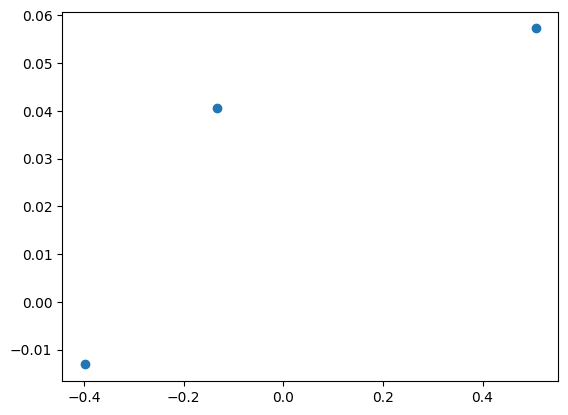

In [35]:
plt.scatter(direct_hits_df['direct_effect'], direct_hits_df['lm_coef'])

### Compute predicted effects for all significant target-condition pairs

In [36]:
from scipy.stats import pearsonr

rng = np.random.default_rng(2314)
all_effects = {}      # (target, condition) -> df with predicted_effect, negctrl_predicted_effect, true_effect
all_direct_hits = {}  # (target, condition) -> df with direct_effect and lm_coef per direct hit gene

conditions = adata_de.obs['culture_condition'].unique().tolist()

for tf in sig_targets:
    for cond in conditions:
        key = (tf, cond)
        df_effects, direct_hits_df = get_predicted_vs_true_effects(
            tf_2_gs_effects, adata_de, c=cond, tf=tf, rng=rng
        )
        has_peak_gs = tf_2_gs_effects[(tf_2_gs_effects['target_contrast_gene_name'] == tf) & (tf_2_gs_effects.culture_condition == 'Stim8hr') & (tf_2_gs_effects.has_peak==1)].gene_name.unique()
        df_effects['direct_hit'] = df_effects.index.isin(has_peak_gs)
        df_effects['target'] = df_effects.index == tf
        all_effects[key] = df_effects
        all_direct_hits[key] = direct_hits_df
        print(f"{tf:10s} {cond:10s}: {len(direct_hits_df):3d} direct hits")


ATF4       Stim8hr   :  11 direct hits
ATF4       Stim48hr  :  33 direct hits
ATF4       Rest      :   3 direct hits
BATF       Stim8hr   :  12 direct hits
BATF       Stim48hr  :   9 direct hits
BATF       Rest      :   3 direct hits
BCL6       Stim8hr   :   4 direct hits
BCL6       Stim48hr  :   5 direct hits
BCL6       Rest      :   1 direct hits
CREBBP     Stim8hr   :  42 direct hits
CREBBP     Stim48hr  :  40 direct hits
CREBBP     Rest      :  24 direct hits
CXXC1      Stim8hr   :   2 direct hits
CXXC1      Stim48hr  :   2 direct hits
CXXC1      Rest      :   1 direct hits
FOSL2      Stim8hr   :   5 direct hits
FOSL2      Stim48hr  :  14 direct hits
FOSL2      Rest      :   3 direct hits
GATA3      Stim8hr   :  67 direct hits
GATA3      Stim48hr  :  70 direct hits
GATA3      Rest      :  63 direct hits
MED12      Stim8hr   :  12 direct hits
MED12      Stim48hr  :   3 direct hits
MED12      Rest      :   7 direct hits
REST       Stim8hr   :  24 direct hits
REST       Stim48hr  :  1

In [37]:
for (tf, cond), hits_df in all_direct_hits.items():
    genes = ', '.join(sorted(hits_df.index))
    print(f"{tf} / {cond} ({len(hits_df)}): {genes}")


ATF4 / Stim8hr (11): BUD31, EPRS1, GOT1, PRNP, PSAT1, SIAH2, SLC38A1, SLC7A5, WARS1, XPOT, YARS1
ATF4 / Stim48hr (33): ANKRD11, CEBPB, CEBPG, CHAC1, DDIT4, EIF1, EIF2S2, EPRS1, ERP29, GOT1, GPT2, HERPUD1, IARS1, MTHFD1L, NARS1, PCK2, PPP1R15B, PRNP, PSAT1, SESN2, SHMT2, SLC1A4, SLC38A1, SLC38A2, SLC6A9, SLC7A1, SLC7A5, STK40, VEGFA, WARS1, XPOT, YARS1, ZFP69B
ATF4 / Rest (3): EIF1, PSAT1, SHMT2
BATF / Stim8hr (12): ADGRG1, BCL9, CD200R1, DENND1B, PGAP1, PIK3CG, RNF149, RNF213, RUNX3, SRGN, SYTL3, TMEM156
BATF / Stim48hr (9): ADGRG1, DMXL1, G0S2, INTS6, RMI2, RNF149, RPP30, TMEM156, TTF2
BATF / Rest (3): ATM, ITGAL, RAD23A
BCL6 / Stim8hr (4): ATP6V0B, FOXJ3, GPBP1L1, USP48
BCL6 / Stim48hr (5): ATP6V0B, FOXJ3, HERC5, PDIK1L, TMEM59
BCL6 / Rest (1): ATP6V0B
CREBBP / Stim8hr (42): ADAT1, AKAP11, ANKFY1, ARHGAP9, ATP5PB, BIRC3, CIAO1, DGUOK, EMG1, ERGIC2, ESYT1, FBXL19, HERC1, HNRNPH3, IL7R, KIAA1143, LAMP1, LRSAM1, LY9, MAK16, MAP2K2, MBOAT7, MITD1, MTA2, NCOA4, NME1, PIK3R2, PRKAG1, PTPN4

In [38]:
# Summarise: Pearson r of predicted vs true effect for each method
summary_rows = []
for (tf, cond), df in all_effects.items():
    df = df[(~df_effects['direct_hit']) & (~df_effects['target'])]  # consider only trans-effects
    df = df.drop('TRDC')
    pl_direct = df.dropna(subset=['true_effect', 'predicted_effect'])
    pl_lm = df.dropna(subset=['true_effect', 'lm_predicted_effect'])
    pl_nc = df.dropna(subset=['true_effect', 'negctrl_predicted_effect'])
    pl_nc_lm = df.dropna(subset=['true_effect', 'lm_negctrl_predicted_effect'])

    r_direct, p_direct = pearsonr(pl_direct['true_effect'], pl_direct['predicted_effect']) if len(pl_direct) > 2 else (np.nan, np.nan)
    r_lm, p_lm = pearsonr(pl_lm['true_effect'], pl_lm['lm_predicted_effect']) if len(pl_lm) > 2 else (np.nan, np.nan)
    r_nc, p_nc = pearsonr(pl_nc['true_effect'], pl_nc['negctrl_predicted_effect']) if len(pl_nc) > 2 else (np.nan, np.nan)
    r_nc_lm, p_nc_lm = pearsonr(pl_nc_lm['true_effect'], pl_nc_lm['lm_negctrl_predicted_effect']) if len(pl_nc_lm) > 2 else (np.nan, np.nan)

    summary_rows.append({
        'target': tf,
        'condition': cond,
        'n_direct_hits': len(all_direct_hits[(tf, cond)]),
        'pearsonr_direct': r_direct,
        'pval_direct': p_direct,
        'pearsonr_lm': r_lm,
        'pval_lm': p_lm,
        'pearsonr_negctrl': r_nc,
        'pval_negctrl': p_nc,
        'pearsonr_negctrl_lm': r_nc_lm,
        'pval_negctrl_lm': p_nc_lm,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['target', 'condition'])
summary_df.sort_values('pearsonr_direct')

,target,condition,n_direct_hits,pearsonr_direct,pval_direct,pearsonr_lm,pval_lm,pearsonr_negctrl,pval_negctrl,pearsonr_negctrl_lm,pval_negctrl_lm
26,REST,Rest,21,-0.164041,1.470858e-57,0.222322,2.369147e-105,0.056578,4.195421e-08,0.258997,1.409051e-143
24,REST,Stim8hr,24,-0.108480,6.073182e-26,0.336068,2.936082e-246,-0.046565,6.453407e-06,0.319871,4.718740e-222
6,BCL6,Stim8hr,4,-0.087830,1.488221e-17,0.088182,1.105753e-17,-0.036924,3.439278e-04,0.131235,2.292506e-37
16,FOSL2,Stim48hr,14,-0.081064,3.700507e-15,0.207398,1.061413e-91,0.050647,9.154235e-07,0.127017,4.673297e-35
30,TRIM28,Stim8hr,1,-0.066327,1.228133e-10,0.066327,1.228133e-10,-0.002139,8.357522e-01,0.002139,8.357522e-01
7,BCL6,Stim48hr,5,-0.062375,1.446014e-09,0.105680,9.652761e-25,-0.095269,2.171039e-20,0.131673,1.330209e-37
9,CREBBP,Stim8hr,42,-0.061359,2.824868e-09,0.343664,9.075510e-258,-0.103927,6.475697e-24,0.361426,4.862242e-287
25,REST,Stim48hr,15,-0.055895,6.023769e-08,0.100599,1.535354e-22,-0.002464,8.113837e-01,0.099945,2.875703e-22
13,CXXC1,Stim48hr,2,-0.046409,6.782572e-06,0.046409,6.782572e-06,-0.107285,1.832428e-25,0.165383,1.312666e-58
35,YY1,Rest,79,-0.039539,1.260379e-04,0.360396,3.083963e-286,-0.014145,1.703162e-01,0.370983,1.734088e-304


### Save results

In [39]:
import os

os.makedirs(RESULTS_DIR, exist_ok=True)

# Save odds ratio results
odds_results_df.to_csv(os.path.join(RESULTS_DIR, "odds_ratio_results.csv"), index=False)

# Save prediction summary
summary_df.to_csv(os.path.join(RESULTS_DIR, "predicted_vs_true_effect_summary.csv"), index=False)

# Save all effects (gene_name preserved as column; 'target' bool kept; TF name in 'tf' column)
all_effects_list = []
for (tf, cond), df in all_effects.items():
    df = df.copy()
    df['tf'] = tf
    df['condition'] = cond
    df.index.name = 'gene_name'
    all_effects_list.append(df.reset_index())
all_effects_df = pd.concat(all_effects_list, ignore_index=True)
all_effects_df.to_csv(os.path.join(RESULTS_DIR, "predicted_vs_true_effects.csv"), index=False)

# Save all direct hits
all_direct_hits_list = []
for (tf, cond), df in all_direct_hits.items():
    df = df.copy()
    df['tf'] = tf
    df['condition'] = cond
    df.index.name = 'gene_name'
    all_direct_hits_list.append(df.reset_index())
all_direct_hits_df = pd.concat(all_direct_hits_list, ignore_index=True)
all_direct_hits_df.to_csv(os.path.join(RESULTS_DIR, "all_direct_hits.csv"), index=False)

print("Saved to", RESULTS_DIR)


Saved to /mnt/oak/users/emma/bin/GWT_perturbseq_analysis/src/9_ChIP_analysis/results


In [40]:
# Reload saved tables
summary_df = pd.read_csv(os.path.join(RESULTS_DIR, "predicted_vs_true_effect_summary.csv"))
odds_results_df = pd.read_csv(os.path.join(RESULTS_DIR, "odds_ratio_results.csv"))
all_effects_df = pd.read_csv(os.path.join(RESULTS_DIR, "predicted_vs_true_effects.csv"))
# all_direct_hits_df = pd.read_csv(os.path.join(RESULTS_DIR, "all_direct_hits.csv"))

# Reconstruct all_effects dict: (tf, condition) -> DataFrame indexed by gene_name
all_effects = {
    (tf, cond): grp.set_index('gene_name').drop(columns=['tf', 'condition'])
    for (tf, cond), grp in all_effects_df.groupby(['tf', 'condition'], sort=False)
}

# Reconstruct all_direct_hits dict: (tf, condition) -> DataFrame indexed by gene_name
all_direct_hits = {
    (tf, cond): grp.set_index('gene_name').drop(columns=['tf', 'condition'])
    for (tf, cond), grp in all_direct_hits_df.groupby(['tf', 'condition'], sort=False)
}

all_effects_df.head()


,gene_name,predicted_effect,lm_predicted_effect,negctrl_predicted_effect,lm_negctrl_predicted_effect,true_effect,direct_hit,target,tf,condition
0,AAAS,-0.188479,0.031888,-0.139673,-0.000773,-0.166511,False,False,ATF4,Stim8hr
1,AACS,-0.174865,-0.023805,0.356707,-0.105006,-0.764661,False,False,ATF4,Stim8hr
2,AAGAB,0.140142,0.009896,-0.068655,-0.009155,-0.059777,False,False,ATF4,Stim8hr
3,AAK1,-0.125380,-0.035705,-0.076171,-0.010682,-0.059194,False,False,ATF4,Stim8hr
4,AAMDC,-0.456694,-0.086680,0.176713,0.000168,1.036923,False,False,ATF4,Stim8hr


Text(0, 0.5, 'pearsonr_direct')

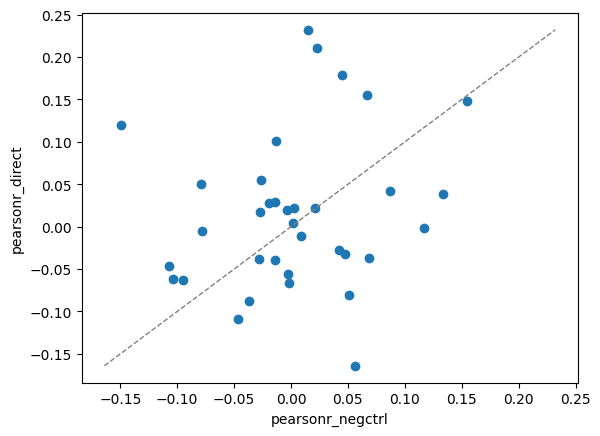

In [44]:
plt.scatter(
    x=summary_df['pearsonr_negctrl'], y=summary_df['pearsonr_direct']
)
# Add diagonal line
min_val = min(summary_df['pearsonr_negctrl'].min(), summary_df['pearsonr_direct'].min())
max_val = max(summary_df['pearsonr_negctrl'].max(), summary_df['pearsonr_direct'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
plt.xlabel('pearsonr_negctrl')
plt.ylabel('pearsonr_direct')


In [46]:
from adjustText import adjust_text

def plot_true_vs_predicted_per_target(all_effects, n_annotate=5, col="predicted_effect"):
    """One figure per target, one subplot per condition.
    Annotates genes with the highest and lowest true effects.
    Adds a linear model trend line in red dashed.
    """
    import numpy as np
    from scipy.stats import pearsonr, linregress

    targets = sorted({tf for tf, _ in all_effects})

    for tf in targets:
        conds = sorted({cond for t, cond in all_effects if t == tf})
        ncols = len(conds)
        fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5), squeeze=False)

        for ax, cond in zip(axes[0], conds):
            data = all_effects[(tf, cond)].dropna(subset=["true_effect", col])
            data = data[(~data['direct_hit']) & (~data['target'])]  # consider only trans-effects
            data = data.drop("TRDC", errors='ignore')
            try:
                x = data["true_effect"].values
                y = data[col].values

                ax.scatter(x, y, s=12, alpha=0.5, linewidths=0, color='black', rasterized=True)

                # Reference lines
                ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
                ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

                # Linear model trend line
                if len(x) > 1 and len(y) > 1:
                    slope, intercept, r, p, stderr = linregress(x, y)
                    xx = np.array([x.min(), x.max()])
                    yy = intercept + slope * xx
                    ax.plot(xx, yy, color="red", linestyle="--", linewidth=1.5, label=f"lm, r={r:.2f}")

                # Pearson r
                r_val, p_val = pearsonr(x, y)
                ax.set_title(f"{cond}\nr = {r_val:.2f}, p = {p_val:.2g}", fontsize=13)
                ax.set_xlabel(f"Measured trans-effects of {tf} KD (log FC)", fontsize=12)
                ax.set_ylabel(f"Estimated trans-effects of {tf} KD\n(from putative cis-targets KD)", fontsize=12)
                ax.tick_params(labelsize=11)

                # Annotate top/bottom n genes by true effect
                top = data.nlargest(n_annotate, "true_effect")
                bot = data.nsmallest(n_annotate, "true_effect")
                to_label = pd.concat([top, bot]).drop_duplicates()

                texts = []
                for gene, row in to_label.iterrows():
                    texts.append(
                        ax.text(row["true_effect"], row[col], gene, fontsize=9, alpha=0.85)
                    )
                adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
            except Exception as e:
                continue

        fig.suptitle(tf, fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"true_vs_predicted_{tf}.pdf"), bbox_inches="tight")
        plt.show()

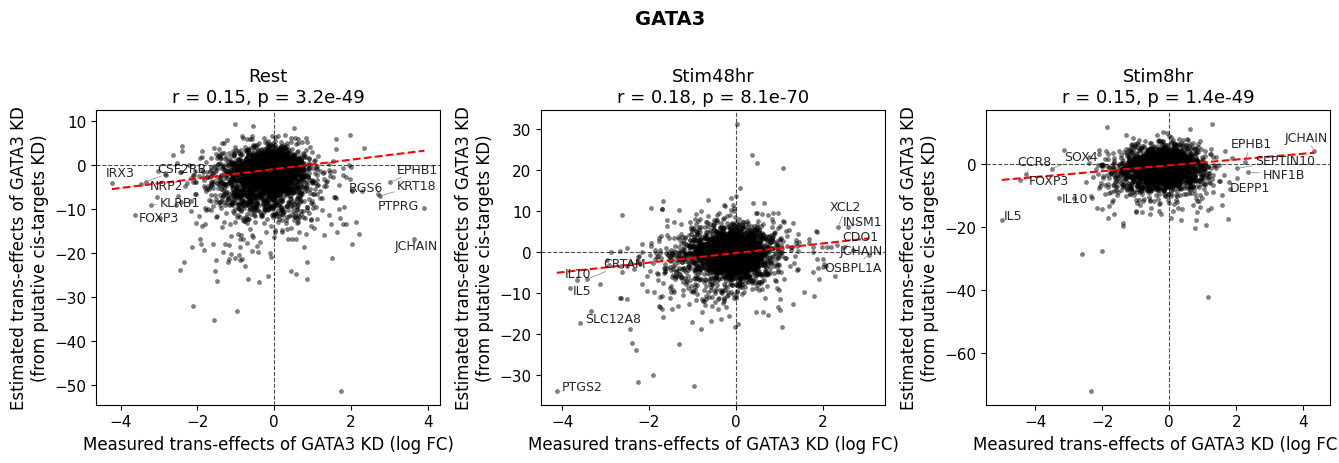

In [51]:
plot_true_vs_predicted_per_target(({k: all_effects[k] for k in [('GATA3', 'Rest'), ('GATA3', 'Stim8hr'), ('GATA3', 'Stim48hr')]}), n_annotate=5, col='predicted_effect')

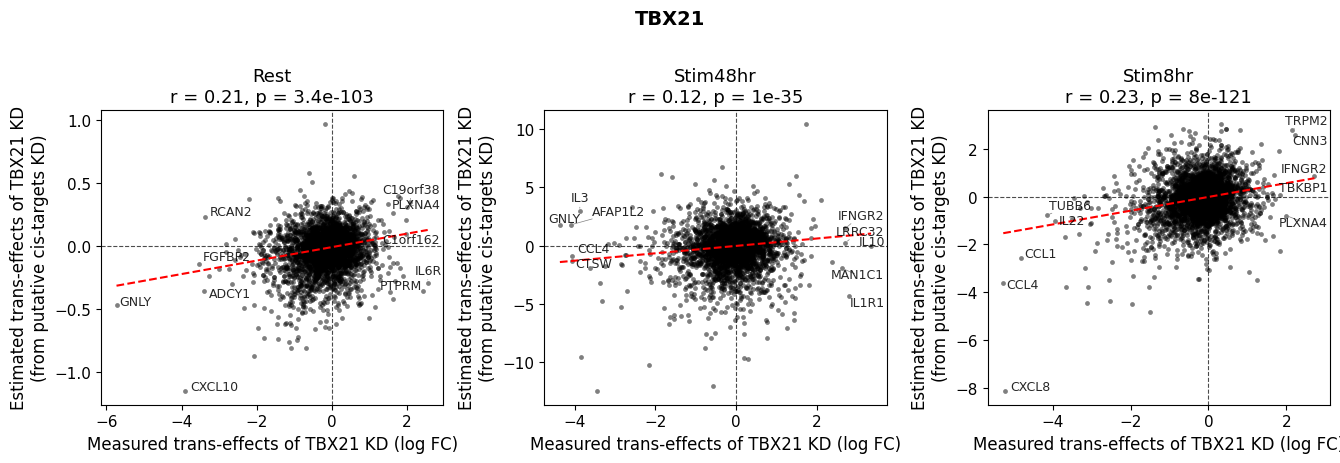

In [50]:
plot_true_vs_predicted_per_target(({k: all_effects[k] for k in [('TBX21', 'Rest'), ('TBX21', 'Stim8hr'), ('TBX21', 'Stim48hr')]}), n_annotate=5, col='predicted_effect')
# plot_true_vs_predicted_per_target(({k: all_effects[k] for k in [('GATA3', 'Rest'), ('GATA3', 'Stim48hr'), ('GATA3', 'Stim8hr')]}), n_annotate=5, col='negctrl_predicted_effect')

In [ ]:
df_effects, direct_hits_df = get_predicted_vs_true_effects(
    tf_2_gs_effects, adata_de, c='Stim8hr', tf='GATA3',
    only_significant_indirect=True, indirect_significance_threshold=0.1
)

df_effects['direct_hit'] = df_effects.index.isin(direct_hits_df.index)
df_effects['target'] = df_effects.index == tf
plot_true_vs_predicted_per_target(({('GATA3', 'Stim8hr'): df_effects}), n_annotate=20, col='predicted_effect')
plot_true_vs_predicted_per_target(({('GATA3', 'Stim8hr'): df_effects}), n_annotate=20, col='negctrl_predicted_effect')

# df_effects[df_effects.index.isin(cytokines)].sort_values('true_effect')

,predicted_effect,lm_predicted_effect,negctrl_predicted_effect,lm_negctrl_predicted_effect,true_effect,direct_hit,target
gene_name,,,,,,,
IL5,1.005903,-0.178090,0.000000,0.000000,-4.998857,False,False
IL13,NaN,NaN,0.000000,0.000000,-4.779840,True,False
IL10,0.691475,-0.175731,0.000000,0.000000,-3.304720,False,False
IL17F,-22.361128,-2.342287,0.110879,-2.343181,-2.342287,False,False
IL4,-0.651266,-0.178450,0.000000,0.000000,-1.732723,False,False
TNFSF10,0.000000,0.000000,-0.062673,0.001479,-0.764331,False,False
IL3,0.122564,-0.021972,0.063591,-0.236120,-0.742300,False,False
IL32,0.000000,0.000000,0.000000,0.000000,-0.704603,False,False
IFNG,0.621294,-0.009905,0.023502,-0.087265,-0.587999,False,False


In [61]:
# df_effects.sort_values('predicted_effect')

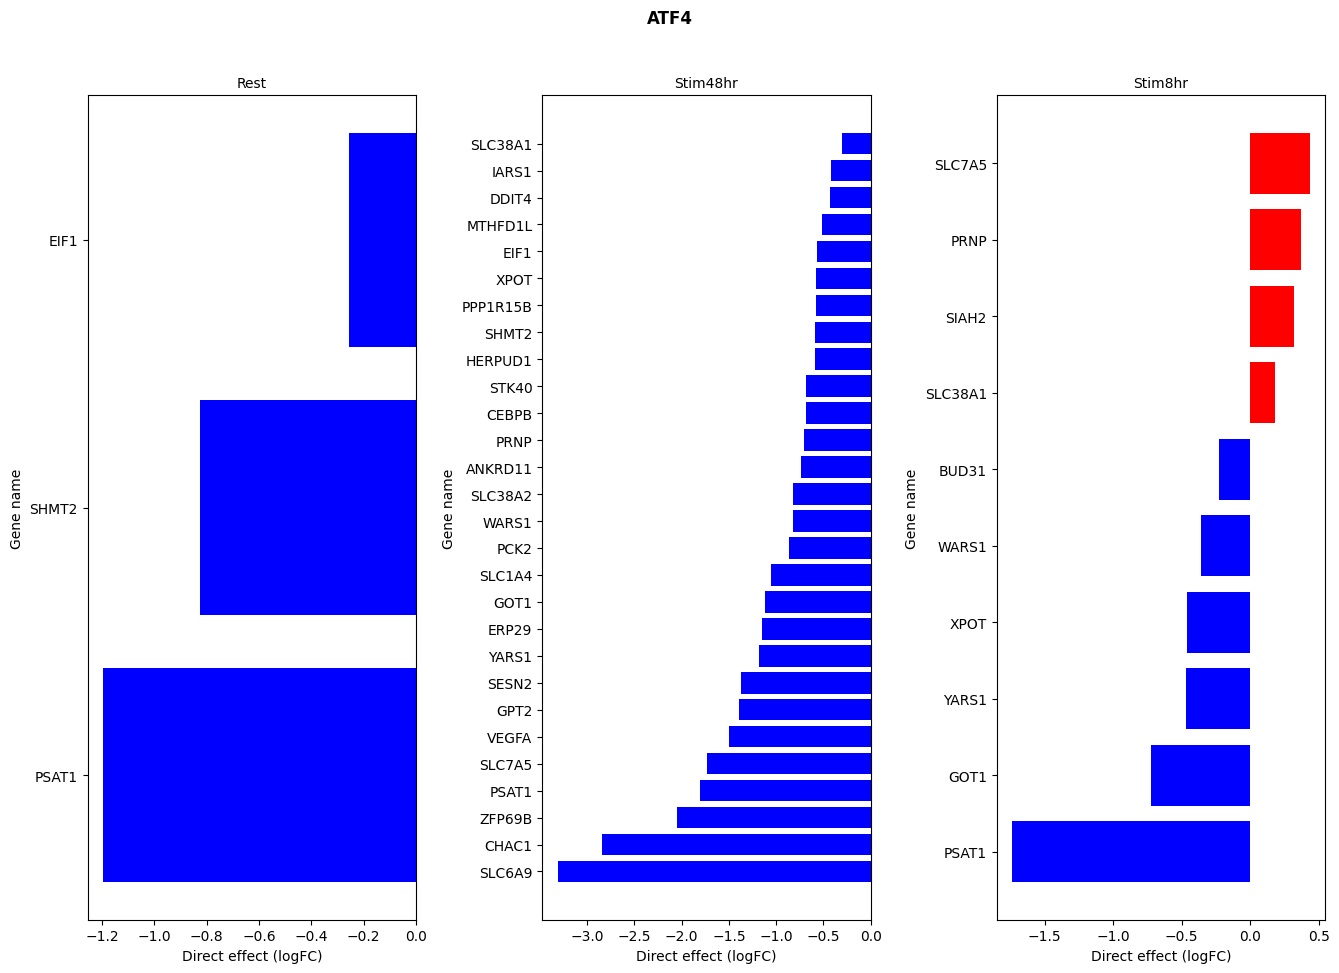

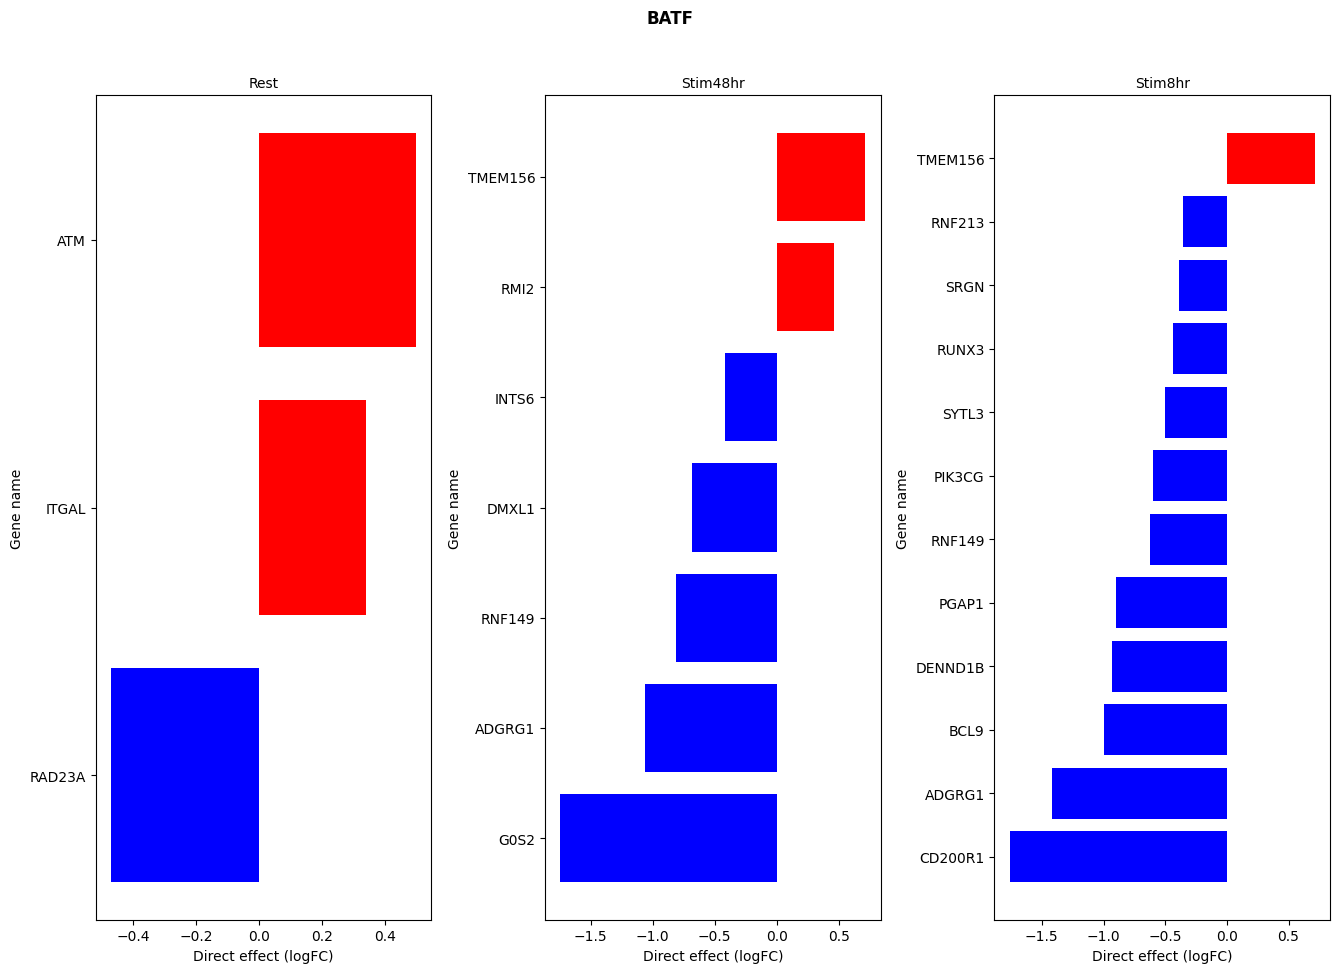

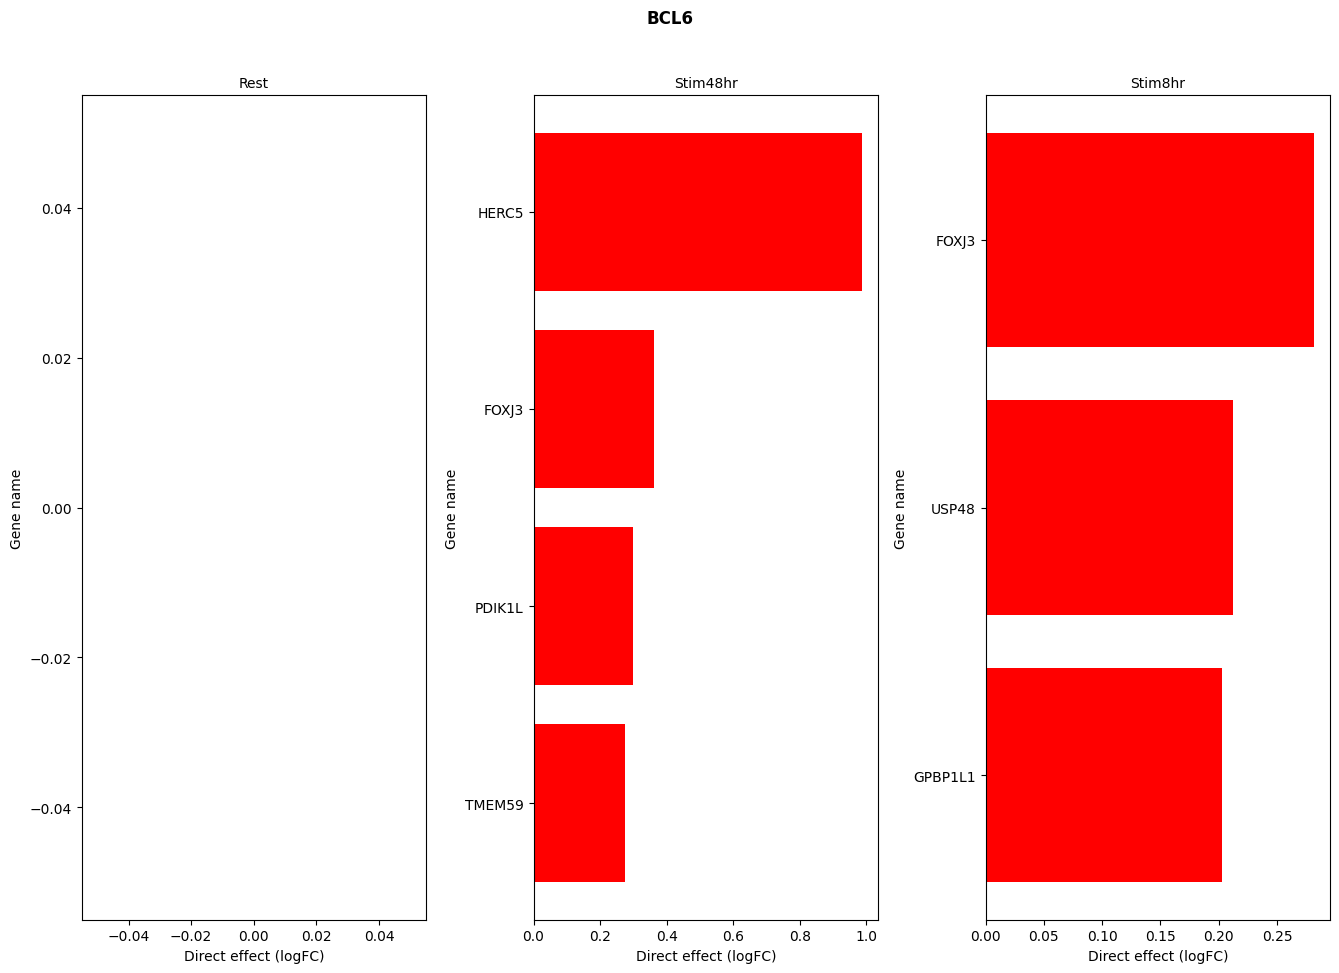

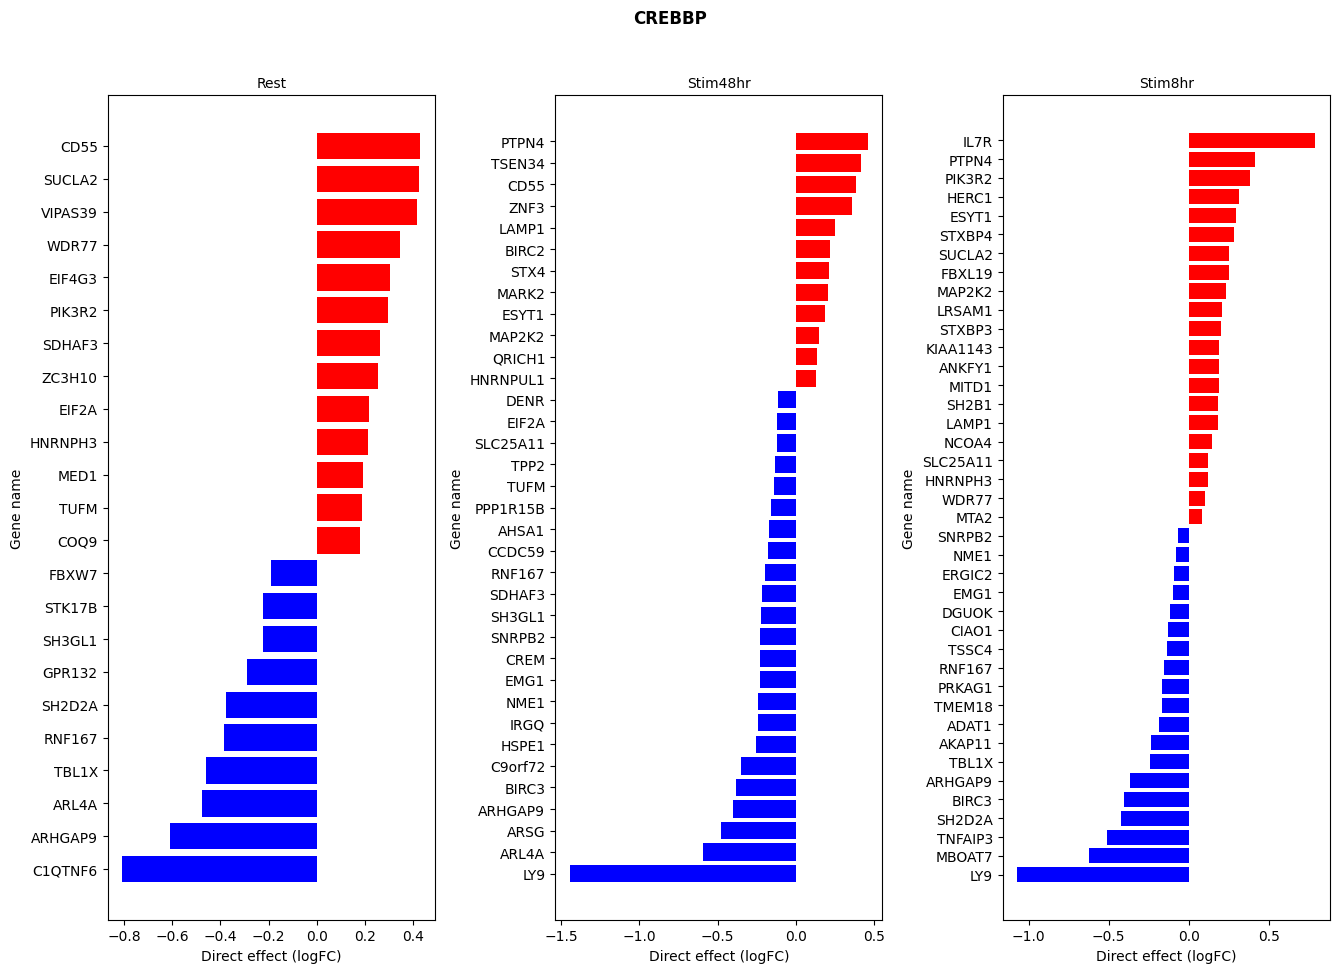

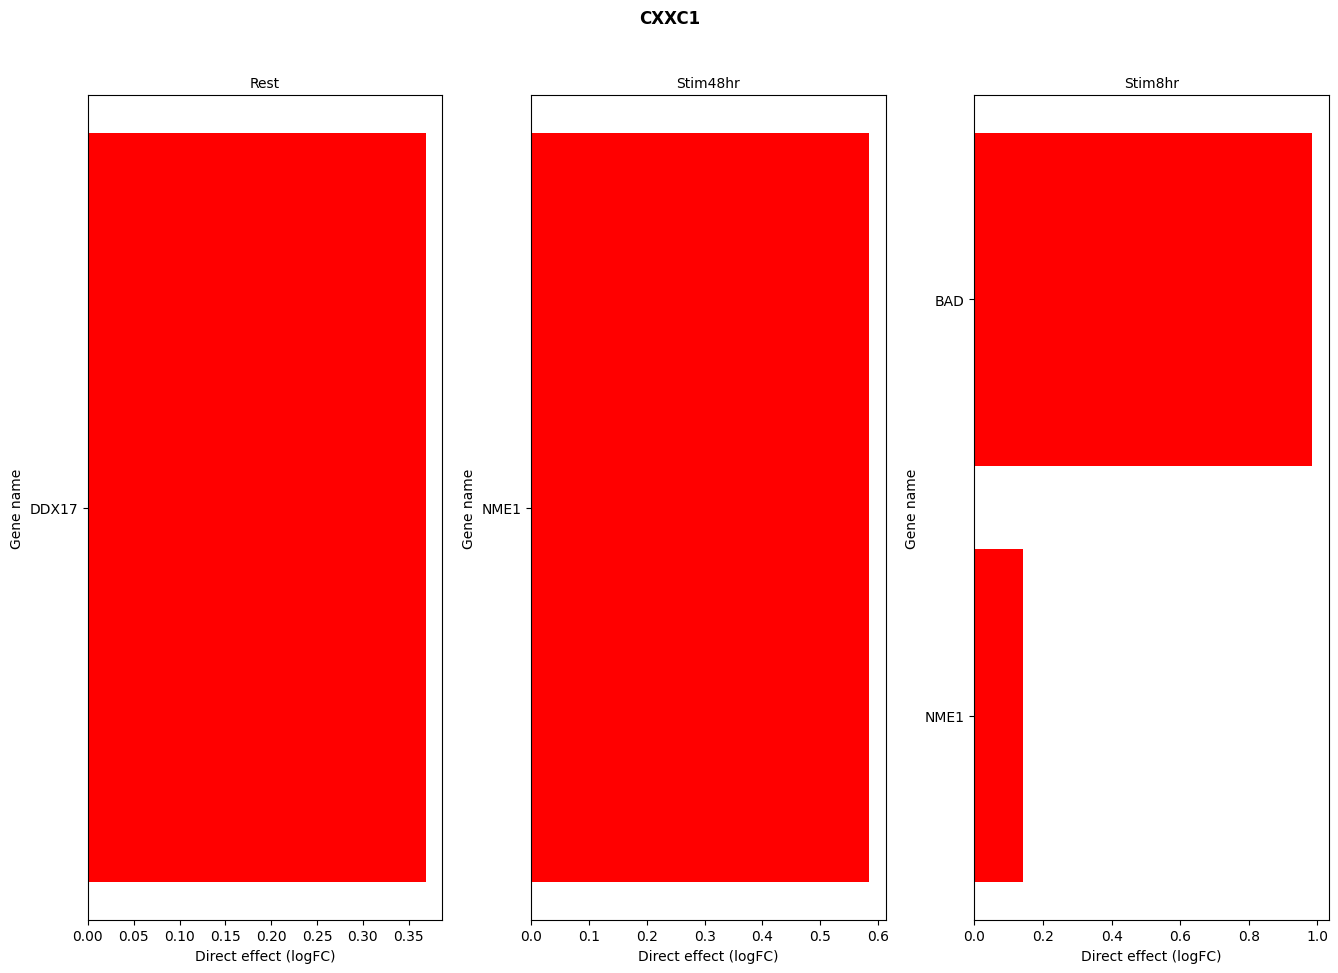

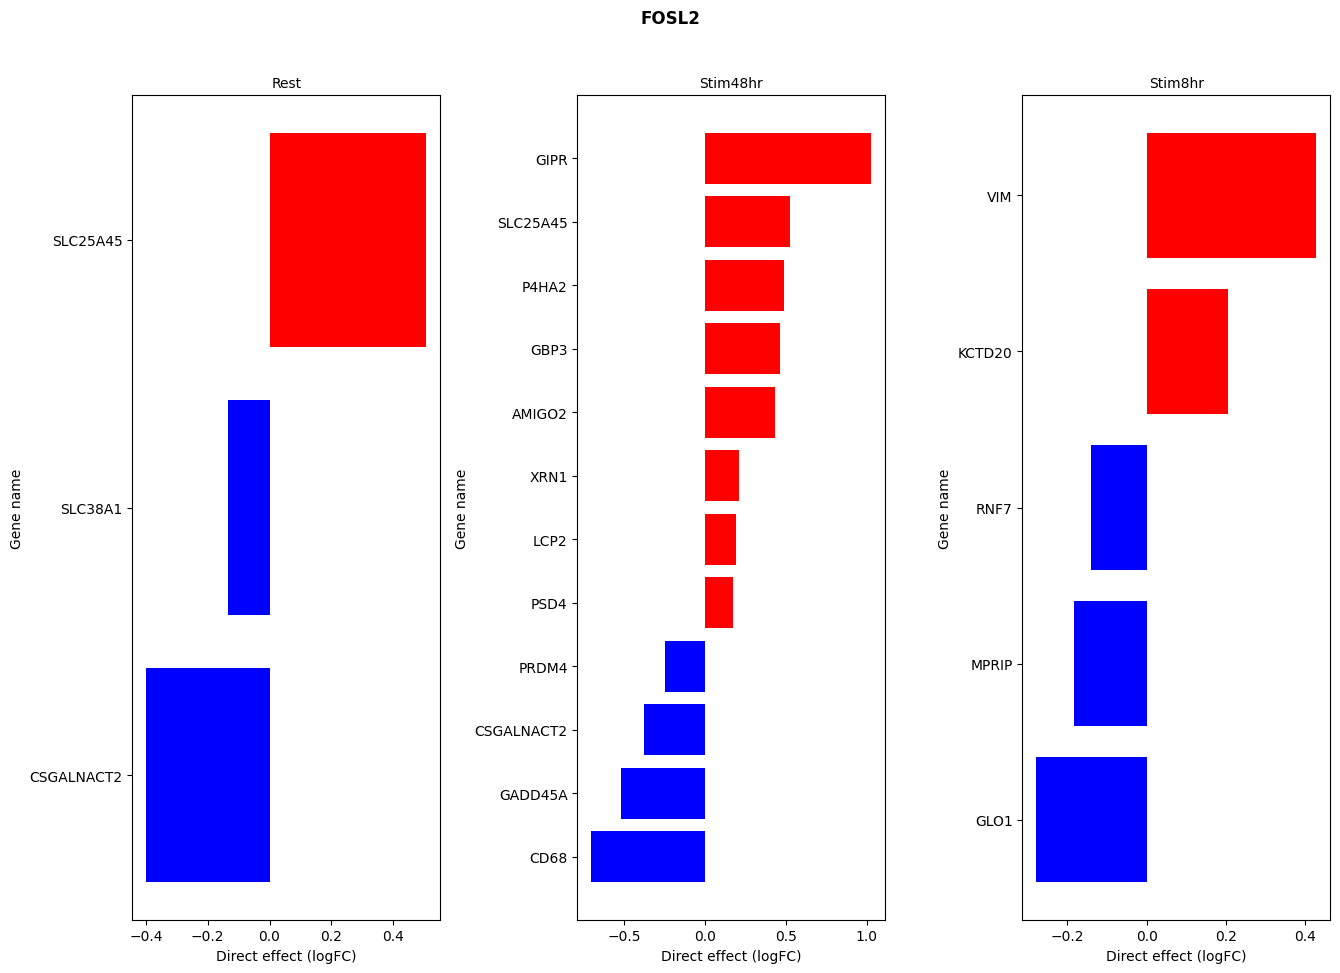

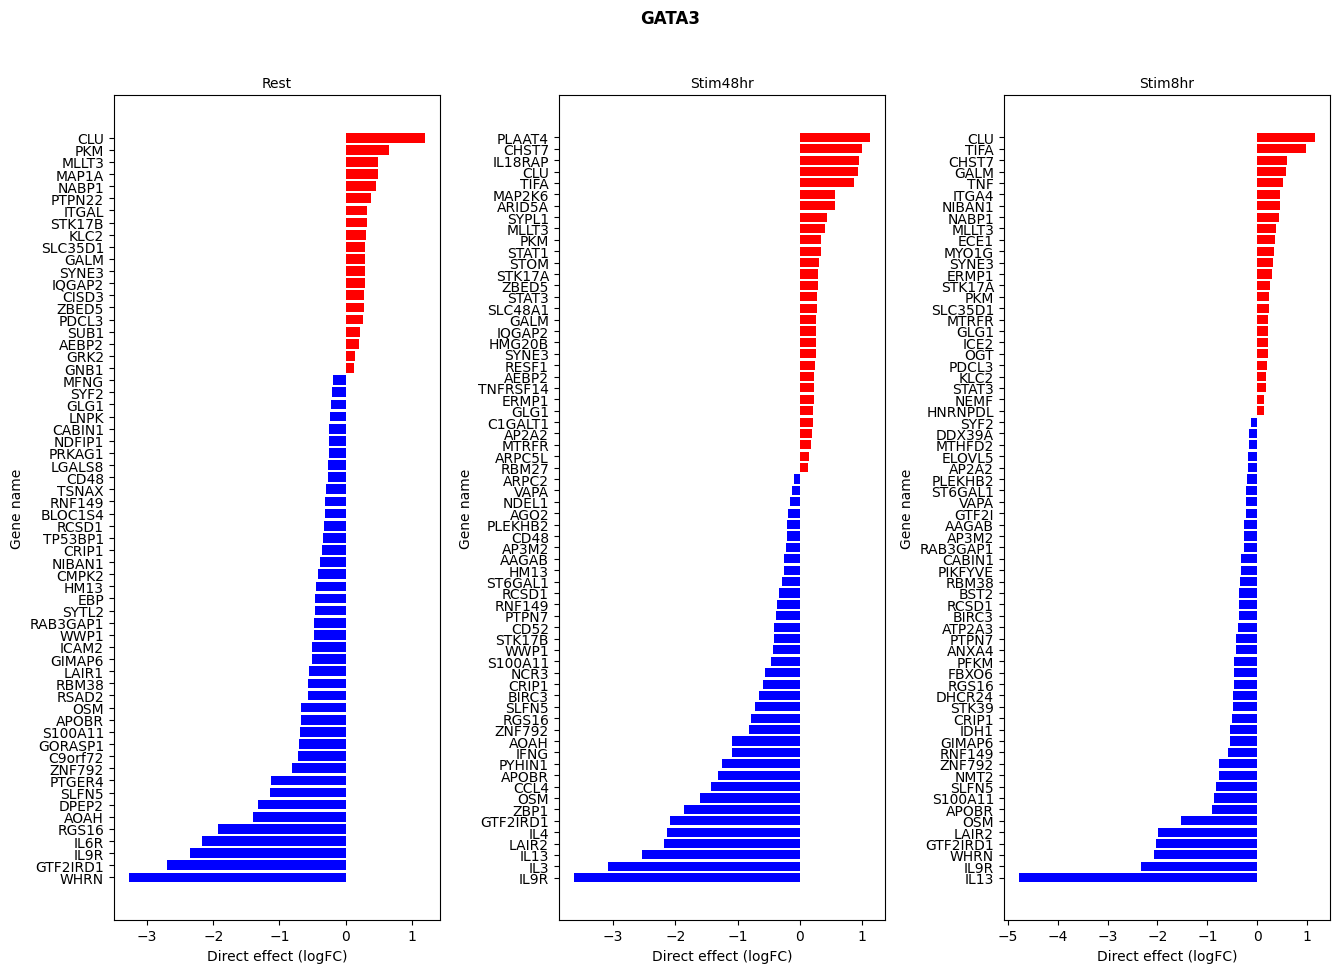

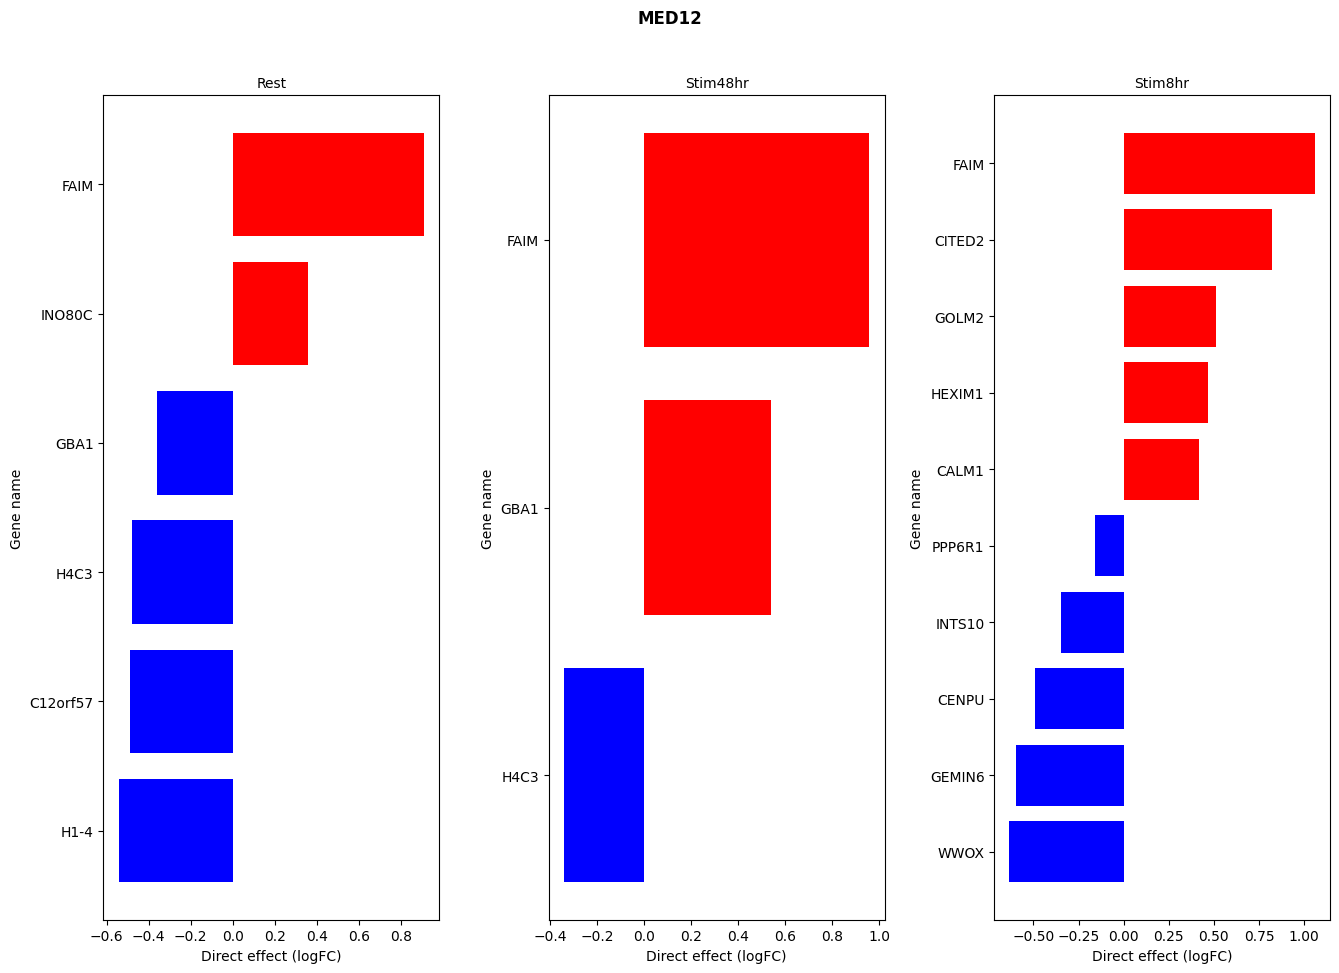

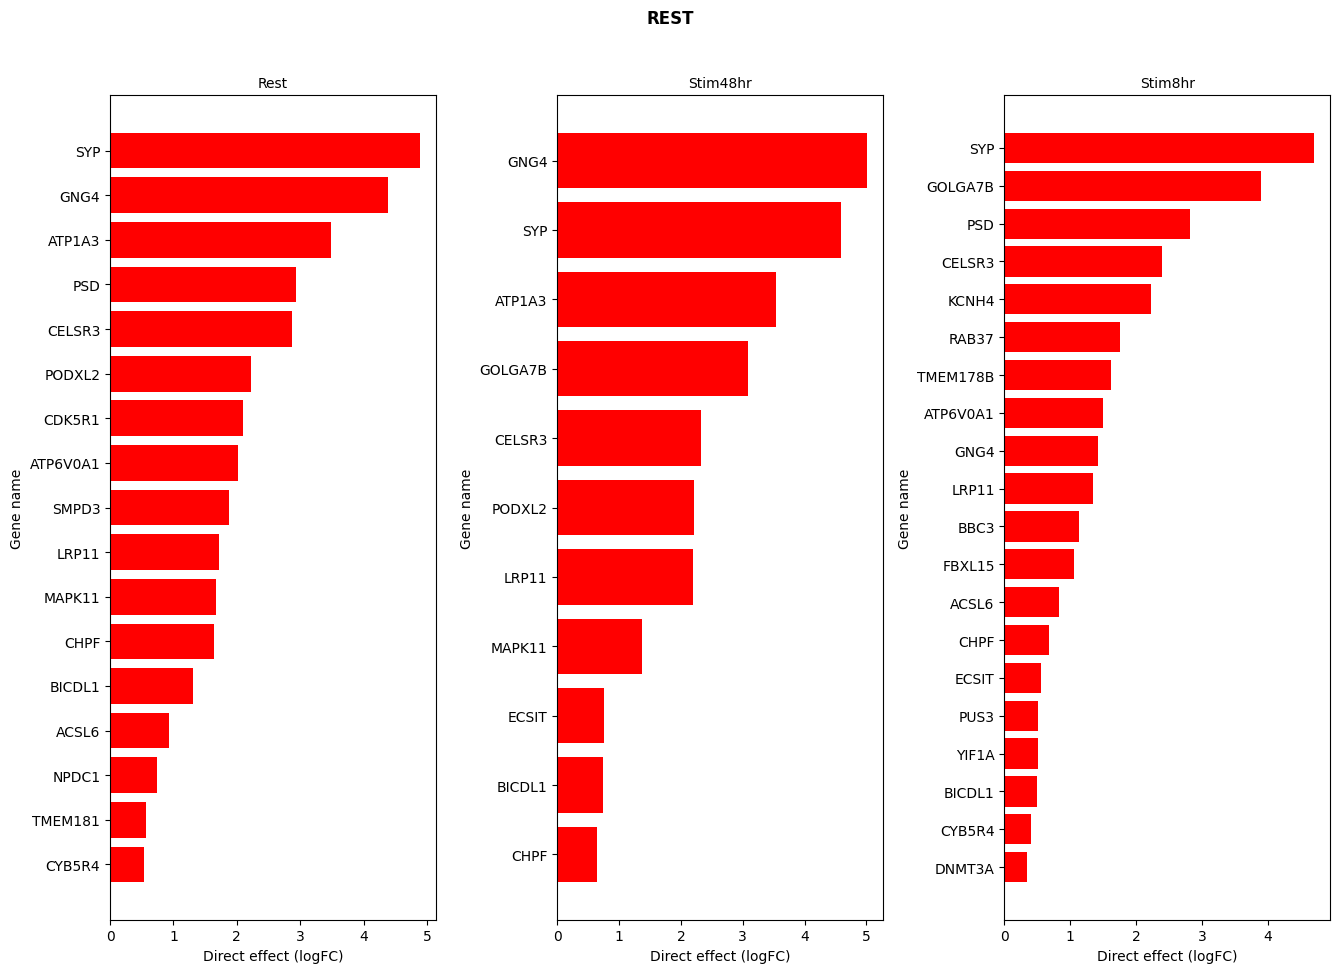

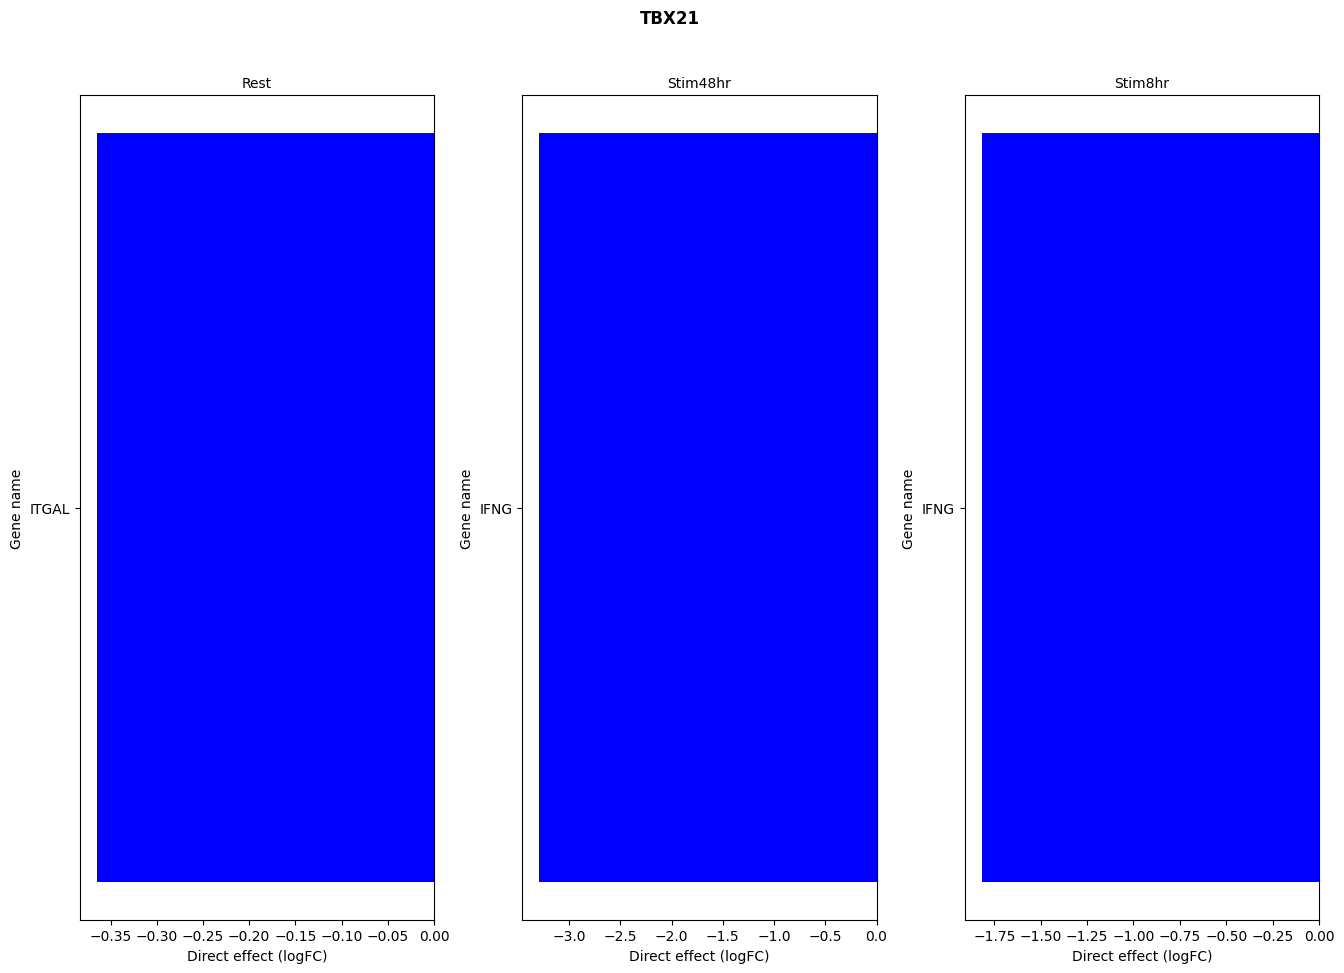

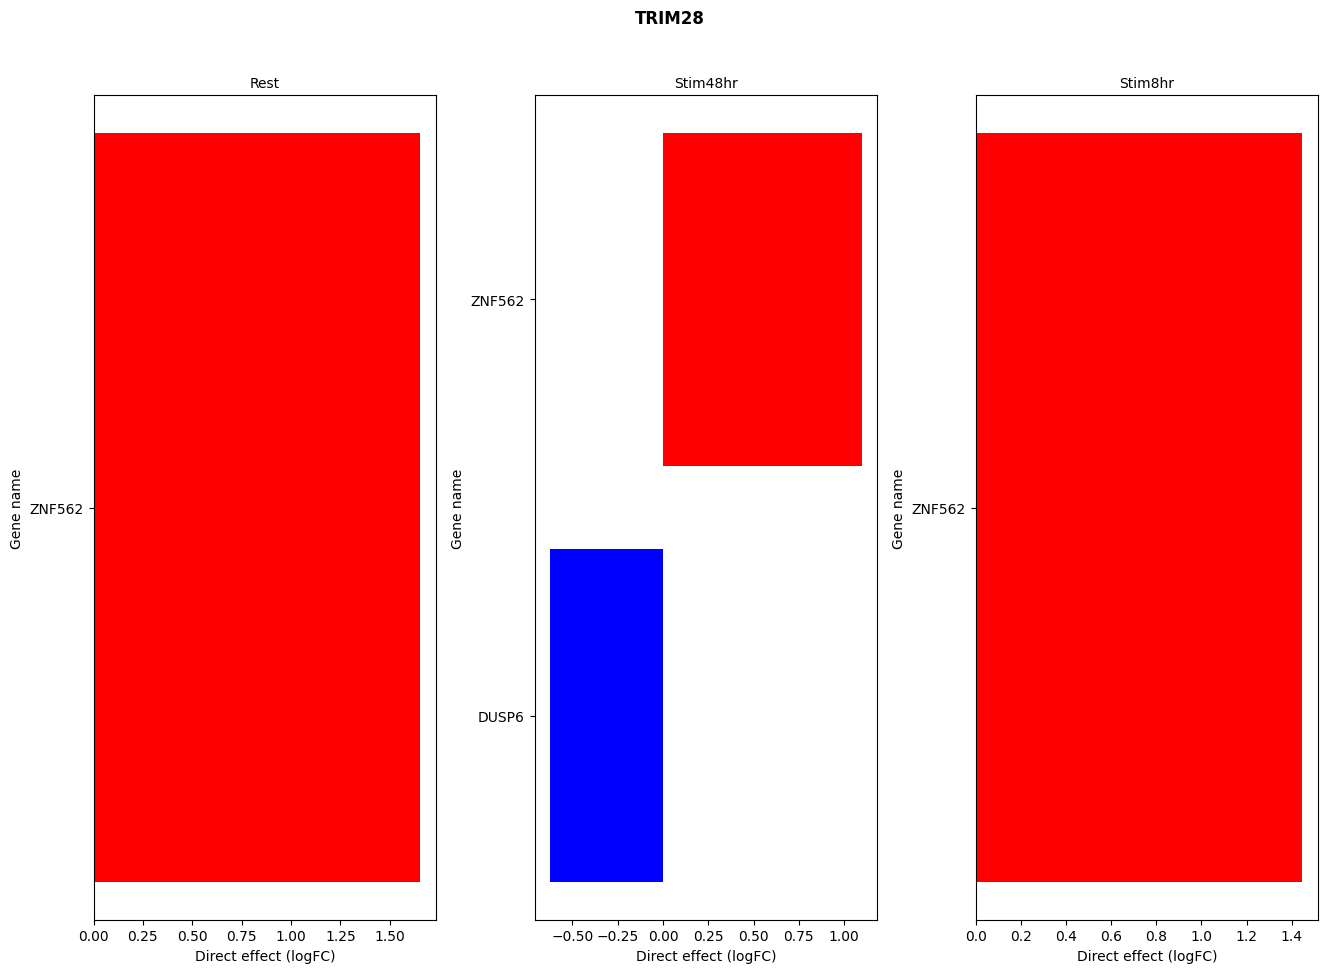

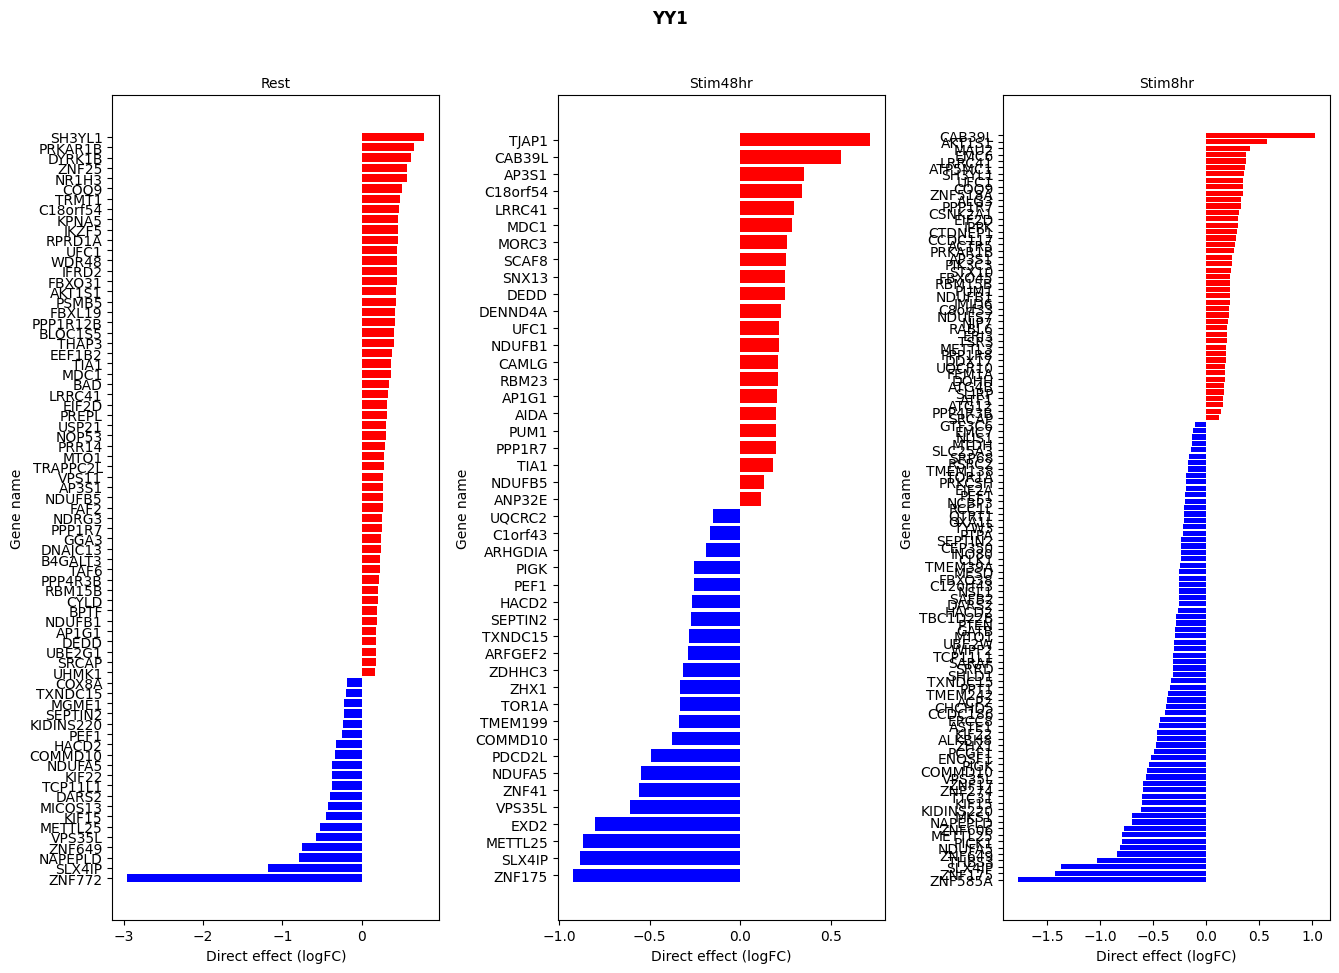

In [63]:
from adjustText import adjust_text

def plot_direct_effect(all_direct_hits):
    """One figure per target, one subplot per condition.
    Scatter of direct_effect (x) vs lm_coef (y) with gene name annotations.
    """
    targets = sorted({tf for tf, _ in all_direct_hits})

    for tf in targets:
        conds = sorted({cond for t, cond in all_direct_hits if t == tf})
        ncols = len(conds)
        fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 9.5), squeeze=False)

        for ax, cond in zip(axes[0], conds):
            data = all_direct_hits[(tf, cond)].dropna(subset=["direct_effect", "lm_coef"]).reset_index()
            data = data.sort_values("direct_effect", ascending=True)
            gene_names = data["gene_name"] if "gene_name" in data.columns else data.index.astype(str)

            # Color by sign of direct_effect
            colors = data["direct_effect"].apply(lambda x: "red" if x > 0 else "blue")

            ax.barh(gene_names, data["direct_effect"], color=colors)
            ax.set_xlabel("Direct effect (logFC)")
            ax.set_ylabel("Gene name")
            ax.set_title(f"{cond}", fontsize=10)

        fig.suptitle(tf, fontsize=12, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"direct_effect_vs_lm_coef_{tf}.pdf"), bbox_inches="tight")
        plt.show()

plot_direct_effect(all_direct_hits)

/tmp/ipykernel_1231572/69547544.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=90)
/tmp/ipykernel_1231572/69547544.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=90)
/tmp/ipykernel_1231572/69547544.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=90)


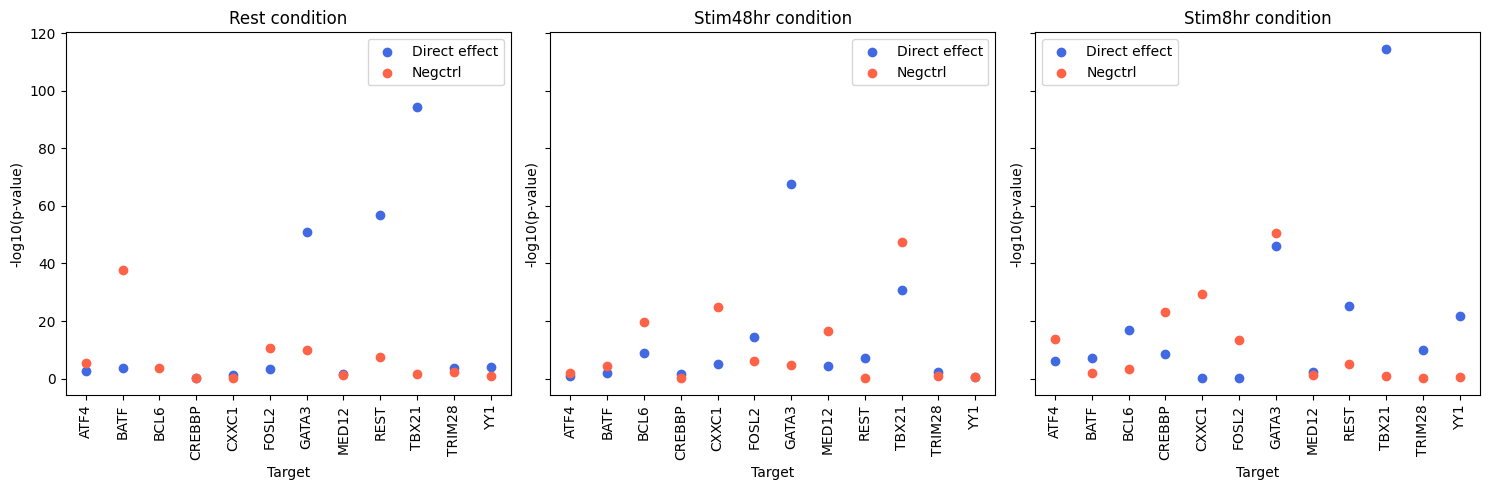

In [177]:
import matplotlib.pyplot as plt

# We assume summary_df has columns: 'target', 'condition', 'pval_direct', 'pval_negctrl'

conditions = summary_df['condition'].unique()
targets = summary_df['target'].unique()

fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 5), sharey=True)

if len(conditions) == 1:
    axes = [axes]  # Make iterable if only 1 subplot

for ax, cond in zip(axes, conditions):
    subset = summary_df[summary_df['condition'] == cond]
    x = subset['target']
    y1 = -np.log10(subset['pval_direct'])
    y2 = -np.log10(subset['pval_negctrl'])

    ax.scatter(x, y1, marker='o', color='royalblue', label='Direct effect')
    ax.scatter(x, y2, marker='o', color='tomato', label='Negctrl')
    ax.set_xticklabels(x, rotation=90)
    ax.set_title(f"{cond} condition")
    ax.set_xlabel("Target")
    ax.set_ylabel("-log10(p-value)")
    ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1231572/3402825346.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)
/tmp/ipykernel_1231572/3402825346.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


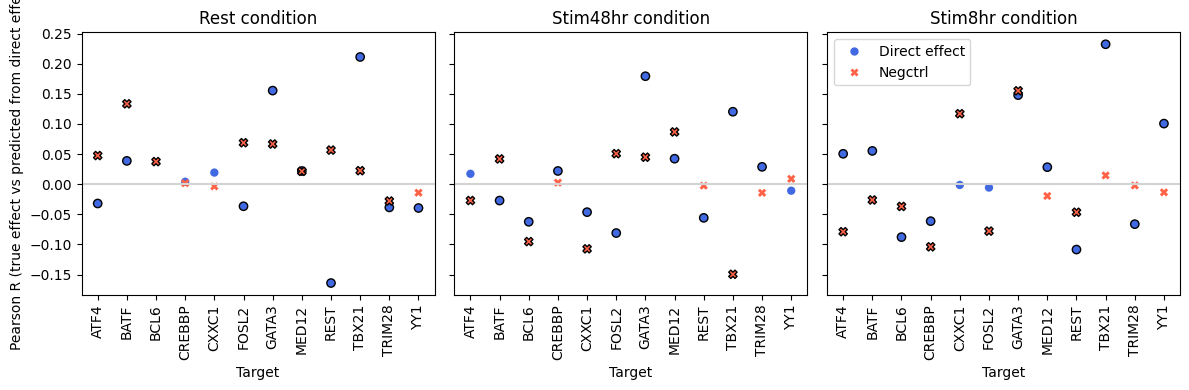

In [193]:
conditions = summary_df['condition'].unique()
targets = summary_df['target'].unique()

fig, axes = plt.subplots(1, len(conditions), figsize=(4 * len(conditions), 4), sharey=True)

if len(conditions) == 1:
    axes = [axes]  # Make iterable if only 1 subplot

import seaborn as sns

for idx, (ax, cond) in enumerate(zip(axes, conditions)):
    subset = summary_df[summary_df['condition'] == cond].copy()

    # Define a fixed, sorted target order for all plots
    all_targets = summary_df['target'].unique()
    target_order = pd.Index(all_targets)  # preserve input order

    # Reindex subset and make sure target is categorical/fixed order
    subset['target'] = pd.Categorical(subset['target'], categories=target_order, ordered=True)

    # Melt dataframe for seaborn plotting
    melted = []
    for label, col, pcol, color in [
        ('Direct effect', 'pearsonr_direct', 'pval_direct', 'royalblue'),
        ('Negctrl', 'pearsonr_negctrl', 'pval_negctrl', 'tomato')
    ]:
        tmp = subset[['target', col, pcol]].copy()
        tmp = tmp.rename(columns={col: 'PearsonR', pcol: 'pval'})
        tmp['type'] = label
        tmp['color'] = color
        tmp['significant'] = tmp['pval'] < 0.05
        melted.append(tmp)
    plot_df = pd.concat(melted, ignore_index=True)

    # Set 'target' to categorical for plot_df as well, with correct order
    plot_df['target'] = pd.Categorical(plot_df['target'], categories=target_order, ordered=True)

    # NS points
    sns.scatterplot(
        data=plot_df[~plot_df['significant']], 
        x='target', y='PearsonR', 
        hue='type',
        palette={'Direct effect': 'royalblue', 'Negctrl': 'tomato'},
        style='type',
        markers=True,
        ax=ax,
        edgecolor="none",
        legend=False if idx < len(axes)-1 else "auto"
    )
    # Significant points
    sns.scatterplot(
        data=plot_df[plot_df['significant']], 
        x='target', y='PearsonR', 
        hue='type',
        palette={'Direct effect': 'royalblue', 'Negctrl': 'tomato'},
        style='type',
        markers=True,
        ax=ax,
        edgecolor="black",
        linewidth=1,
        legend=False if idx < len(axes)-1 else "auto"
    )

    ax.axhline(y=0, color='lightgrey')
    # Set correct x-ticks and labels based on fixed order
    ax.set_xticks(range(len(target_order)))
    ax.set_xticklabels(target_order, rotation=90)
    ax.set_title(f"{cond} condition")
    ax.set_xlabel("Target")
    ax.set_ylabel("Pearson R (true effect vs predicted from direct effect)")
    
    # Show legend only on last subplot
    if idx == len(axes) - 1:
        # Remove duplicate labels in legend
        handles, labels = ax.get_legend_handles_labels()
        seen = set()
        new_handles, new_labels = [], []
        for h, l in zip(handles, labels):
            if l not in seen:
                new_handles.append(h)
                new_labels.append(l)
                seen.add(l)
        ax.legend(new_handles, new_labels)
    else:
        ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

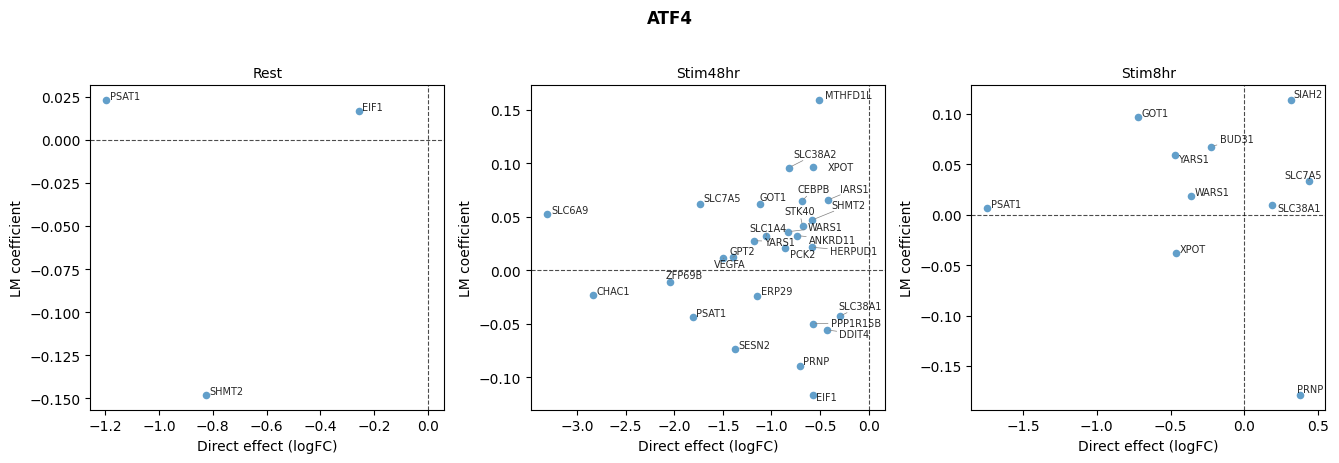

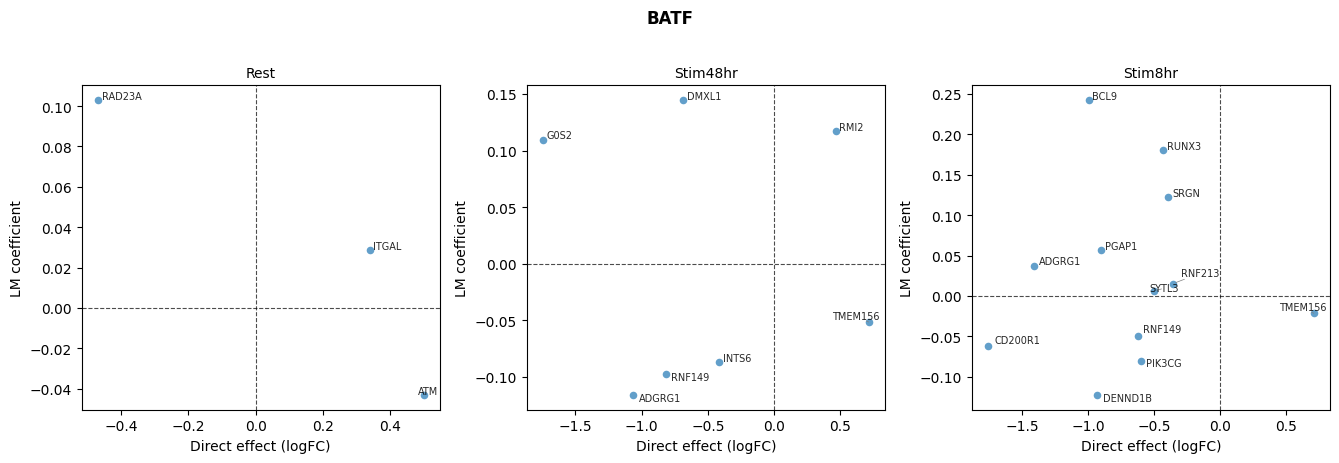

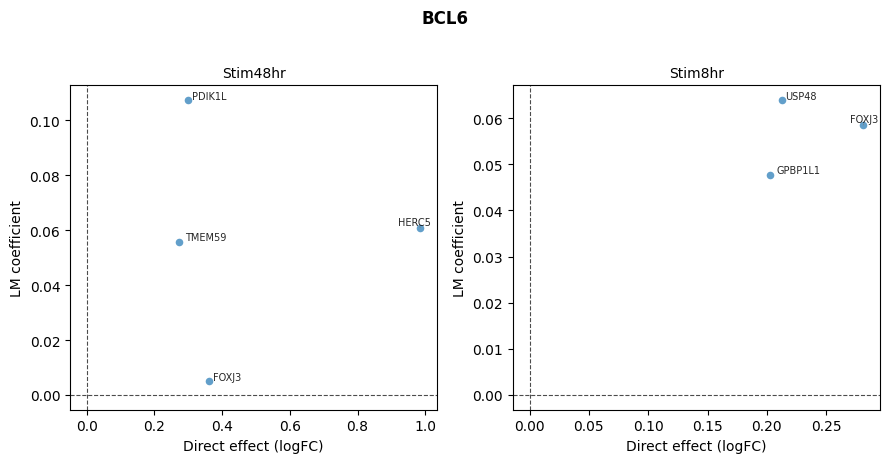

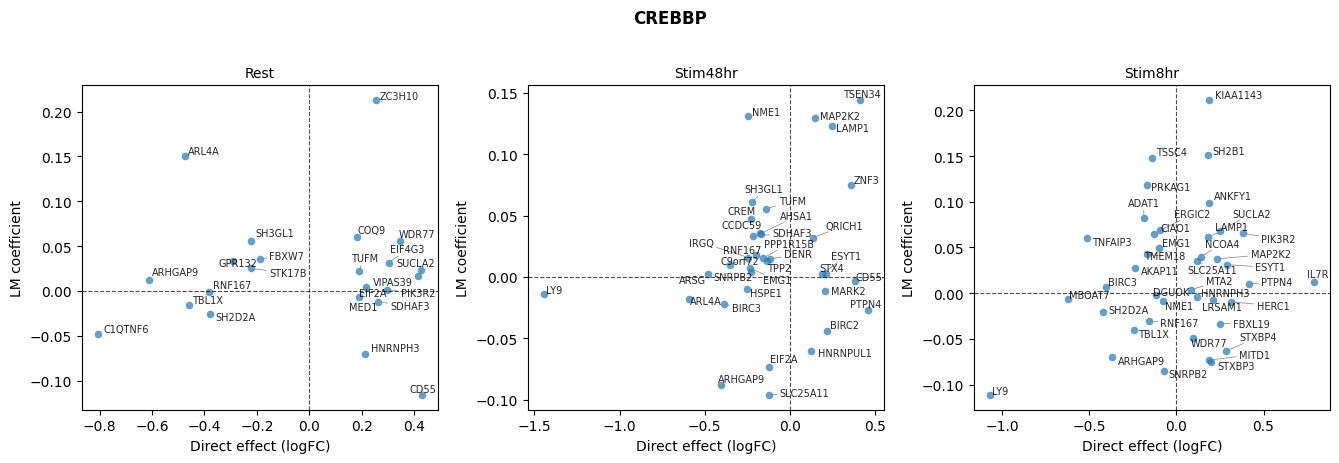

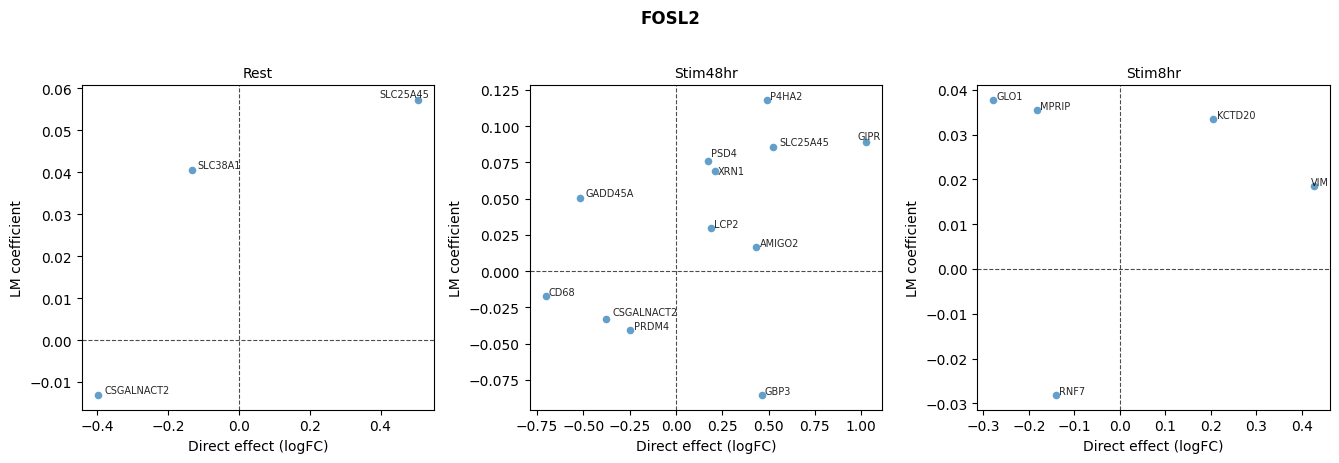

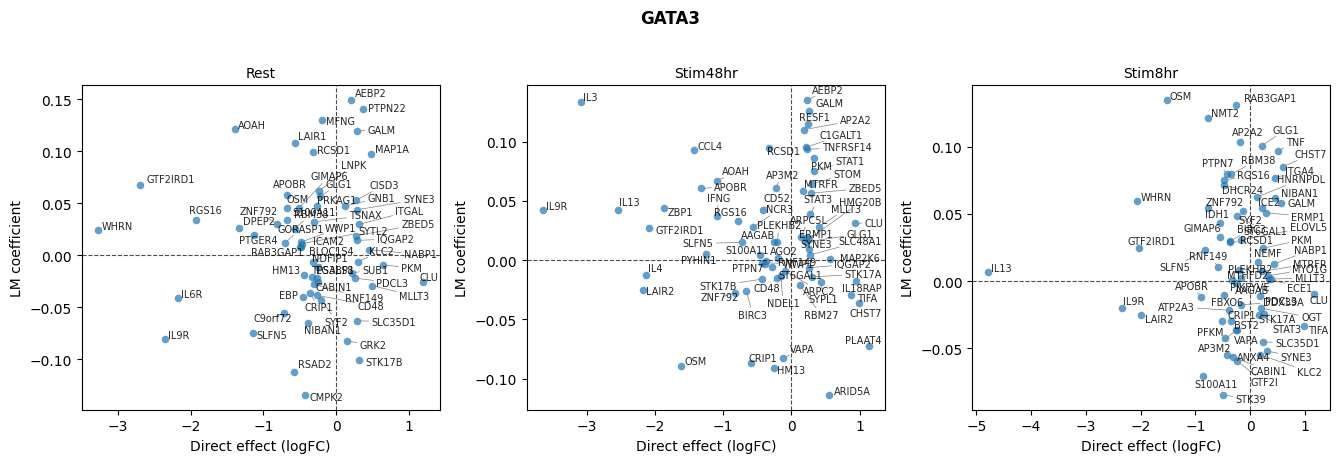

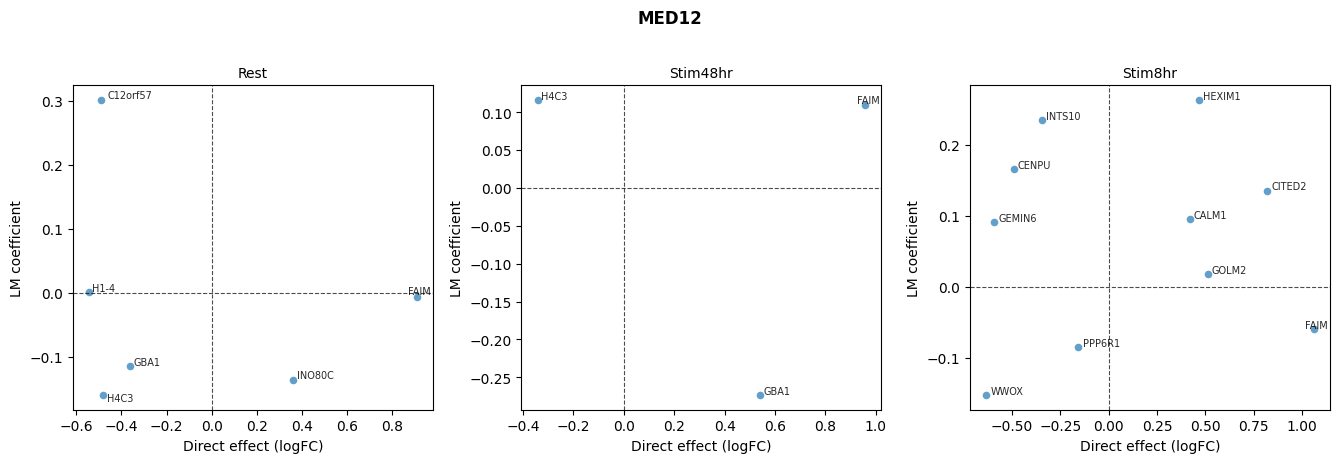

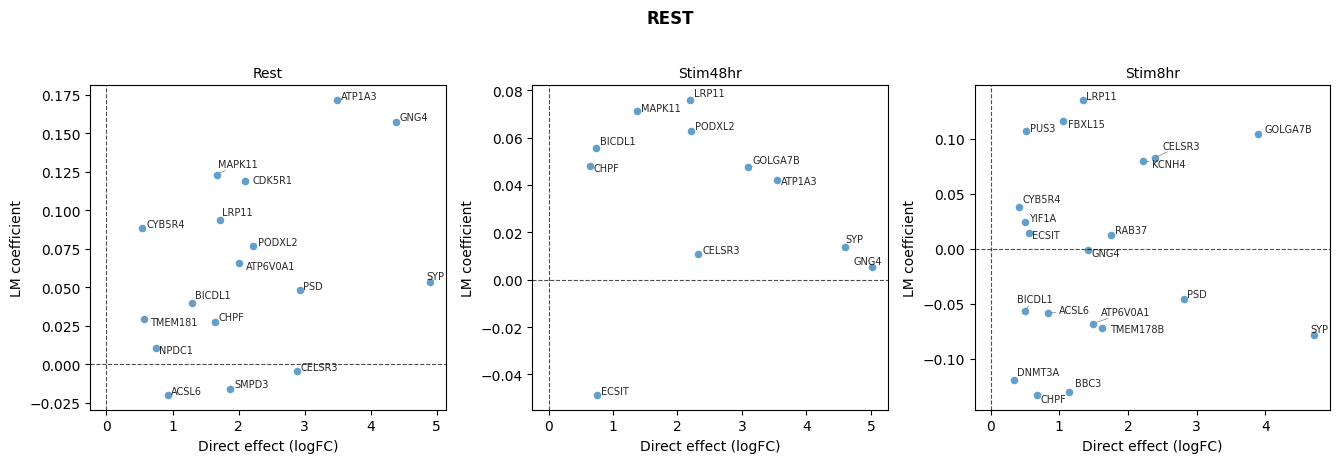

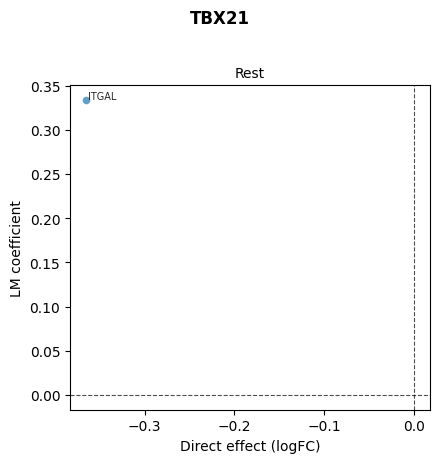

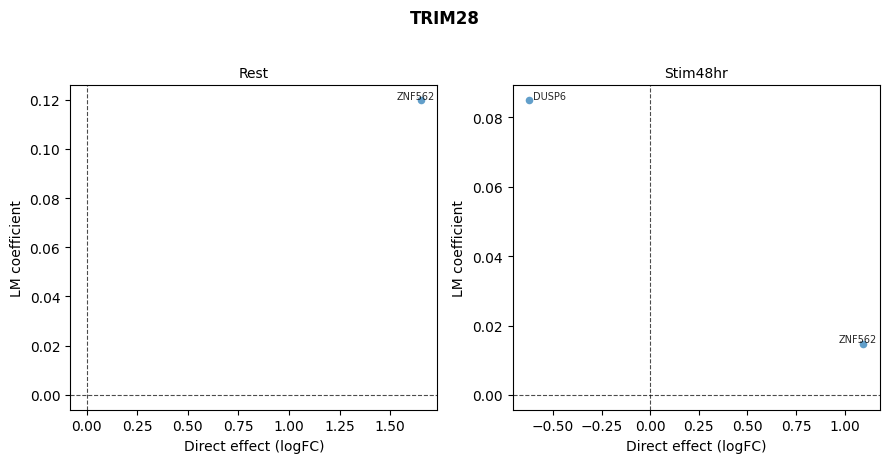

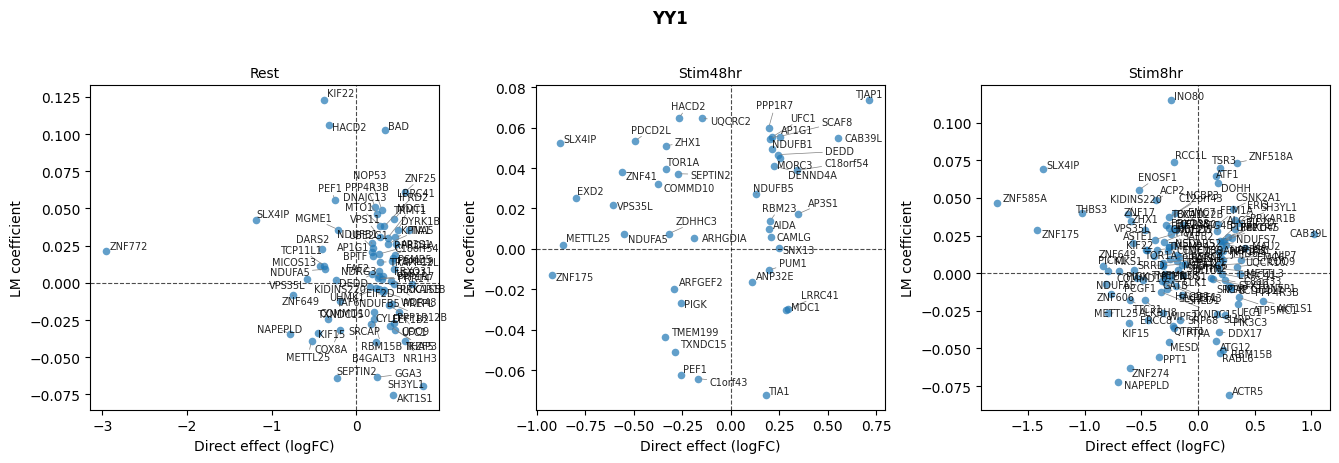

In [ ]:
# from adjustText import adjust_text

# def plot_direct_effect_vs_lm_coef(all_direct_hits):
#     """One figure per target, one subplot per condition.
#     Scatter of direct_effect (x) vs lm_coef (y) with gene name annotations.
#     """
#     targets = sorted({tf for tf, _ in all_direct_hits})

#     for tf in targets:
#         conds = sorted({cond for t, cond in all_direct_hits if t == tf})
#         ncols = len(conds)
#         fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 4.5), squeeze=False)

#         for ax, cond in zip(axes[0], conds):
#             data = all_direct_hits[(tf, cond)].dropna(subset=["direct_effect", "lm_coef"])

#             ax.scatter(data["direct_effect"], data["lm_coef"], s=30, alpha=0.7, linewidths=0)

#             ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
#             ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)

#             ax.set_title(f"{cond}", fontsize=10)
#             ax.set_xlabel(f"Direct effect (logFC)")
#             ax.set_ylabel("LM coefficient")

#             texts = []
#             for gene, row in data.iterrows():
#                 texts.append(
#                     ax.text(row["direct_effect"], row["lm_coef"], gene, fontsize=7, alpha=0.85)
#                 )
#             adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

#         fig.suptitle(tf, fontsize=12, fontweight="bold", y=1.02)
#         plt.tight_layout()
#         plt.savefig(os.path.join(RESULTS_DIR, f"direct_effect_vs_lm_coef_{tf}.pdf"), bbox_inches="tight")
#         plt.show()

# plot_direct_effect_vs_lm_coef(all_direct_hits)

### GATA3 & TBX21: direct prediction vs. 10 random negative controls

For GATA3 and TBX21, compare the Pearson r of direct-effect prediction against a distribution of 10 independently sampled negative controls (non-significant genes with a ChIP peak, matched in number to the direct hits).

In [52]:
# Run 10 negative control samples for GATA3 and TBX21 and compute Pearson r per run
# Two neg ctrl types:
#   (1) peak_nonsig: non-significant genes with a ChIP peak (existing neg ctrl)
#   (2) random:      any genes, regardless of peak or DE significance
focus_tfs = ['GATA3', 'TBX21']
n_negctrl_runs = 10
conditions_all = adata_de.obs['culture_condition'].unique().tolist()

def _trans_pearsonr(df_eff, tf, effect_col):
    """Filter to trans-effects (not a direct hit, not the TF itself) and return Pearson r."""
    has_peak_gs = tf_2_gs_effects[
        (tf_2_gs_effects['target_contrast_gene_name'] == tf) &
        (tf_2_gs_effects.culture_condition == 'Stim8hr') &
        (tf_2_gs_effects.has_peak == 1)
    ].gene_name.unique()
    df = df_eff.copy()
    df['_direct_hit'] = df.index.isin(has_peak_gs)
    df['_self'] = df.index == tf
    df_trans = df[(~df['_direct_hit']) & (~df['_self'])]
    df_trans = df_trans.drop('TRDC', errors='ignore')
    pl = df_trans.dropna(subset=['true_effect', effect_col])
    if len(pl) > 2:
        return pearsonr(pl['true_effect'], pl[effect_col])
    return (np.nan, np.nan)

def _random_negctrl_pearsonr(tf_2_gs_effects, adata_de, tf, cond, n_sample, rng, effect_col='log_fc'):
    """
    Random negative control: sample n_sample genes from ALL genes (excluding the TF itself),
    regardless of peak or DE significance. Mirrors the neg-ctrl weighted-sum prediction.
    """
    onetarget = tf_2_gs_effects[
        (tf_2_gs_effects.target_contrast_gene_name == tf) &
        (tf_2_gs_effects.culture_condition == cond)
    ].drop_duplicates()

    candidates = onetarget[onetarget['gene_name'] != tf].gene_name.unique().tolist()
    if n_sample == 0 or len(candidates) < n_sample:
        return np.nan, np.nan

    sampled = rng.choice(candidates, size=n_sample, replace=False).tolist()
    sampled_effect = onetarget[onetarget['gene_name'].isin(sampled)].set_index('gene_name')[effect_col]

    indirect_long = get_DE_results_long(adata_de, targets=sampled)
    indirect_long = indirect_long[indirect_long['culture_condition'] == cond]
    indirect = indirect_long.pivot(index='gene_name', columns='target_contrast_gene_name', values=effect_col)
    indirect = indirect.drop(sampled, errors='ignore')

    if len(indirect) == 0:
        return np.nan, np.nan

    predicted = (indirect * -sampled_effect.reindex(indirect.columns)).sum(1)
    true_effect = onetarget.set_index('gene_name')[effect_col]

    has_peak_gs = tf_2_gs_effects[
        (tf_2_gs_effects['target_contrast_gene_name'] == tf) &
        (tf_2_gs_effects.culture_condition == 'Stim8hr') &
        (tf_2_gs_effects.has_peak == 1)
    ].gene_name.unique()

    df = pd.DataFrame({'predicted': predicted, 'true': true_effect}).dropna()
    df = df[~df.index.isin(has_peak_gs)]
    df = df[df.index != tf]
    df = df.drop('TRDC', errors='ignore')

    if len(df) > 2:
        return pearsonr(df['true'], df['predicted'])
    return np.nan, np.nan

# --- Direct effect r (from already-computed all_effects) ---
direct_r_rows = []
for tf in focus_tfs:
    for cond in conditions_all:
        if (tf, cond) not in all_effects:
            continue
        r, p = _trans_pearsonr(all_effects[(tf, cond)], tf, 'predicted_effect')
        direct_r_rows.append({'target': tf, 'condition': cond, 'pearsonr': r, 'pval': p})
direct_r_df = pd.DataFrame(direct_r_rows)

# --- 10 independent runs for both neg ctrl types ---
negctrl_r_rows = []
run_seeds = np.random.SeedSequence(9999).spawn(n_negctrl_runs)

for run_i, seed in enumerate(run_seeds):
    run_rng = np.random.default_rng(seed)
    for tf in focus_tfs:
        for cond in conditions_all:
            # (1) peak_nonsig neg ctrl (existing)
            df_run, _ = get_predicted_vs_true_effects(
                tf_2_gs_effects, adata_de, c=cond, tf=tf, rng=run_rng
            )
            r_nc, p_nc = _trans_pearsonr(df_run, tf, 'negctrl_predicted_effect')
            negctrl_r_rows.append({
                'target': tf, 'condition': cond, 'run': run_i,
                'pearsonr': r_nc, 'pval': p_nc, 'negctrl_type': 'peak_nonsig',
            })

            # (2) random neg ctrl — n_sample matched to number of direct hits
            n_direct = len(all_direct_hits.get((tf, cond), pd.DataFrame()))
            r_rand, p_rand = _random_negctrl_pearsonr(
                tf_2_gs_effects, adata_de, tf, cond, n_direct, run_rng
            )
            negctrl_r_rows.append({
                'target': tf, 'condition': cond, 'run': run_i,
                'pearsonr': r_rand, 'pval': p_rand, 'negctrl_type': 'random',
            })

negctrl_r_df = pd.DataFrame(negctrl_r_rows)
print("Direct r:")
print(direct_r_df.to_string(index=False))
print("\nNeg ctrl r summary (mean across runs):")
print(negctrl_r_df.groupby(['target', 'condition', 'negctrl_type'])['pearsonr'].mean().unstack())

Direct r:
target condition  pearsonr          pval
 GATA3   Stim8hr  0.147777  1.381579e-49
 GATA3  Stim48hr  0.175907  8.088485e-70
 GATA3      Rest  0.147216  3.215154e-49
 TBX21   Stim8hr  0.227634 7.980792e-121
 TBX21  Stim48hr  0.122656  1.013622e-35
 TBX21      Rest  0.210485 3.422716e-103

Neg ctrl r summary (mean across runs):
negctrl_type      peak_nonsig    random
target condition                       
GATA3  Rest          0.082202  0.038824
       Stim48hr      0.030985  0.039737
       Stim8hr       0.070607  0.075880
TBX21  Rest         -0.027610  0.023801
       Stim48hr     -0.033377 -0.048121
       Stim8hr      -0.051944  0.044691


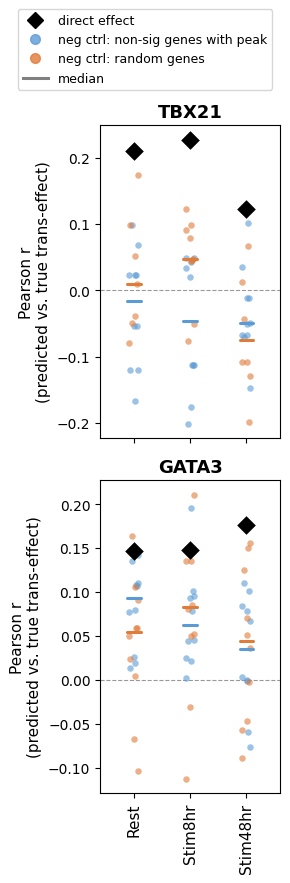

In [66]:
# Plot: direct prediction Pearson r vs. two types of negative controls (n=10 each)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

condition_order = ['Rest', 'Stim8hr', 'Stim48hr']
nc_palette = {'peak_nonsig': '#5b9bd5', 'random': '#e07b39'}
plot_tfs = ['TBX21', 'GATA3']  # TBX21 on top

fig, axes = plt.subplots(len(plot_tfs), 1, figsize=(3, 4.0 * len(plot_tfs)), sharex=True, sharey=False)
x_positions = {c: i for i, c in enumerate(condition_order)}

for ax, tf in zip(axes, plot_tfs):
    tf_nc     = negctrl_r_df[negctrl_r_df['target'] == tf]
    tf_direct = direct_r_df[direct_r_df['target'] == tf]

    for nc_type, color in nc_palette.items():
        data_nc = tf_nc[tf_nc['negctrl_type'] == nc_type].copy()

        for cond_i, cond in enumerate(condition_order):
            vals = data_nc[data_nc['condition'] == cond]['pearsonr'].dropna().values
            if len(vals) == 0:
                continue
            jitter = np.random.default_rng(0).uniform(-0.08, 0.08, size=len(vals))
            ax.scatter(cond_i + jitter, vals, color=color, s=22, alpha=0.6,
                       linewidths=0, zorder=3)
            med = np.median(vals)
            ax.plot([cond_i - 0.12, cond_i + 0.12], [med, med],
                    color=color, linewidth=2.2, solid_capstyle='round', zorder=4)

    # Direct effect diamond
    for _, row in tf_direct.iterrows():
        x_pos = x_positions.get(row['condition'], np.nan)
        ax.scatter(x_pos, row['pearsonr'], color='black', s=90, zorder=5,
                   marker='D', linewidths=0)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(tf, fontsize=13, fontweight='bold')
    ax.set_ylabel('Pearson r\n(predicted vs. true trans-effect)', fontsize=11)
    ax.tick_params(axis='y', labelsize=10)
    ax.set_xlim(-0.6, len(condition_order) - 0.4)

axes[-1].set_xticks(range(len(condition_order)))
axes[-1].set_xticklabels(condition_order, fontsize=11, rotation=90)
axes[-1].set_xlabel('')

legend_handles = [
    Line2D([0], [0], marker='D', color='black', linewidth=0, markersize=8,
           label='direct effect'),
    Line2D([0], [0], marker='o', color=nc_palette['peak_nonsig'], linewidth=0,
           markersize=7, alpha=0.8, label='neg ctrl: non-sig genes with peak'),
    Line2D([0], [0], marker='o', color=nc_palette['random'], linewidth=0,
           markersize=7, alpha=0.8, label='neg ctrl: random genes'),
    Line2D([0], [0], color='gray', linewidth=2.2, label='median'),
]
fig.legend(handles=legend_handles, fontsize=9, framealpha=0.8,
           loc='upper center', bbox_to_anchor=(0.5, 1.1),
           ncol=1, borderaxespad=0.1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gata3_tbx21_negctrl_comparison.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(RESULTS_DIR, 'gata3_tbx21_negctrl_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()

In [44]:
negctrl_r_df[(negctrl_r_df['condition'] == 'Rest') & (negctrl_r_df['target'] == 'GATA3')]['pval']

2     3.471767e-20
8     5.880335e-03
14    1.722329e-74
20    2.095394e-06
26    2.459007e-73
32    6.159131e-01
38    6.995258e-03
44    6.614543e-22
50    2.325420e-36
56    2.476818e-46
Name: pval, dtype: float64

## Effects of GATA3 on cytokines

In [73]:
imm_genes = pd.read_csv('../../metadata/immune_effector_genes.csv')
cytokines = imm_genes[imm_genes['Category'] == 'Cytokine']['gene_name'].tolist()

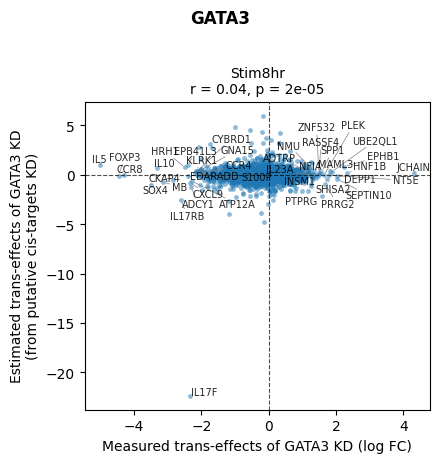

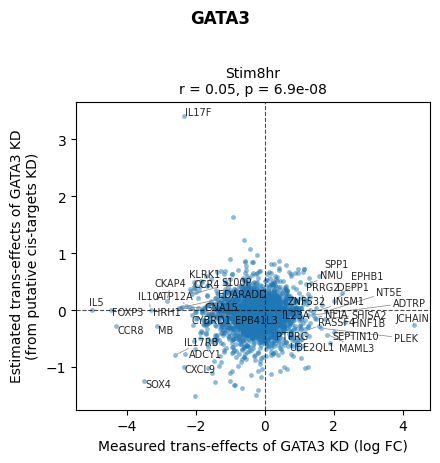

,predicted_effect,lm_predicted_effect,negctrl_predicted_effect,lm_negctrl_predicted_effect,true_effect,direct_hit,target
gene_name,,,,,,,
IL5,1.005903,-0.178090,0.000000,0.000000,-4.998857,False,False
IL13,NaN,NaN,0.052851,-0.229832,-4.779840,True,False
IL10,0.691475,-0.175731,0.000000,0.000000,-3.304720,False,False
IL17F,-22.361128,-2.342287,3.420648,-1.247229,-2.342287,False,False
IL4,-0.651266,-0.178450,0.053344,-0.057440,-1.732723,False,False
TNFSF10,0.000000,0.000000,-0.089974,-0.073163,-0.764331,False,False
IL3,0.122564,-0.021972,-0.057088,0.123491,-0.742300,False,False
IL32,0.000000,0.000000,0.000000,0.000000,-0.704603,False,False
IFNG,0.621294,-0.009905,-0.174022,0.055827,-0.587999,False,False


In [74]:
df_effects, direct_hits_df = get_predicted_vs_true_effects(
    tf_2_gs_effects, adata_de, c='Stim8hr', tf='GATA3',
    only_significant_indirect=True, indirect_significance_threshold=0.1
)

df_effects['direct_hit'] = df_effects.index.isin(direct_hits_df.index)
df_effects['target'] = df_effects.index == tf
plot_true_vs_predicted_per_target(({('GATA3', 'Stim8hr'): df_effects}), n_annotate=20, col='predicted_effect')
plot_true_vs_predicted_per_target(({('GATA3', 'Stim8hr'): df_effects}), n_annotate=20, col='negctrl_predicted_effect')

df_effects[df_effects.index.isin(cytokines)].sort_values('true_effect')

In [75]:
putative_direct_hits = all_direct_hits[('GATA3', 'Stim8hr')].index.tolist()

In [76]:
tf = 'GATA3'
c = 'Stim8hr'
gata3_cytokine_effects = tf_2_gs_effects[
    (tf_2_gs_effects['culture_condition'] == c) &
    (tf_2_gs_effects['target_contrast_gene_name'] == tf) &
    (tf_2_gs_effects['gene_name'].isin(cytokines))
]
gata3_cytokine_effects.sort_values('adj_p_value')

,index,gene,log_fc,zscore,adj_p_value,significant,gene_name,culture_condition,target_contrast,target_contrast_gene_name,has_peak
332988,ENSG00000107485_Stim8hr,IL13,-4.779840,-9.515037,4.530749e-18,True,IL13,Stim8hr,ENSG00000107485,GATA3,1.0
333005,ENSG00000107485_Stim8hr,IL23A,1.321720,6.669882,9.459987e-09,True,IL23A,Stim8hr,ENSG00000107485,GATA3,0.0
337901,ENSG00000107485_Stim8hr,TNFSF10,-0.764331,-5.894258,8.534148e-07,True,TNFSF10,Stim8hr,ENSG00000107485,GATA3,0.0
333014,ENSG00000107485_Stim8hr,IL32,-0.704603,-5.523364,5.530076e-06,True,IL32,Stim8hr,ENSG00000107485,GATA3,0.0
333019,ENSG00000107485_Stim8hr,IL5,-4.998857,-4.560027,3.092694e-04,True,IL5,Stim8hr,ENSG00000107485,GATA3,0.0
337584,ENSG00000107485_Stim8hr,TGFB1,-0.481685,-4.370472,6.442340e-04,True,TGFB1,Stim8hr,ENSG00000107485,GATA3,0.0
332981,ENSG00000107485_Stim8hr,IL10,-3.304720,-4.254055,9.497948e-04,True,IL10,Stim8hr,ENSG00000107485,GATA3,0.0
332991,ENSG00000107485_Stim8hr,IL16,-0.493899,-3.337780,1.504576e-02,True,IL16,Stim8hr,ENSG00000107485,GATA3,0.0
333680,ENSG00000107485_Stim8hr,LTA,0.627244,3.128955,2.589135e-02,True,LTA,Stim8hr,ENSG00000107485,GATA3,0.0
338492,ENSG00000107485_Stim8hr,VEGFB,-0.296674,-2.926653,4.173901e-02,True,VEGFB,Stim8hr,ENSG00000107485,GATA3,0.0


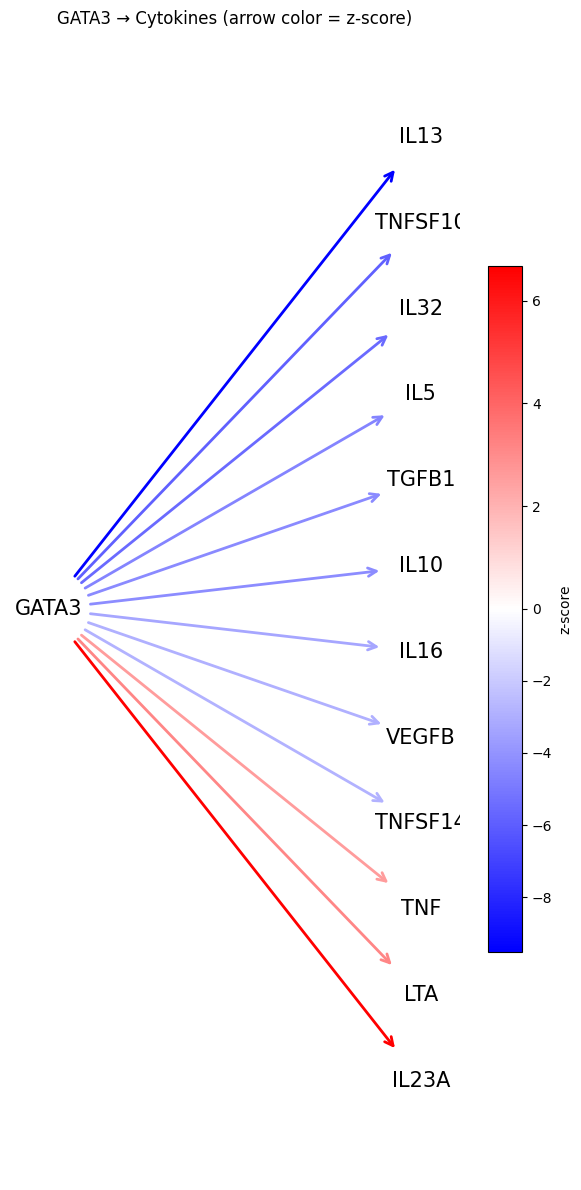

In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

# Filter relevant edges and sort downstream genes by zscore
pl_df = gata3_cytokine_effects[gata3_cytokine_effects['adj_p_value'] < 0.1].copy()
pl_df = pl_df.sort_values('zscore', ascending=False)

# Create a directed graph
G = nx.DiGraph()
source_nodes = pl_df['target_contrast_gene_name'].unique()
target_nodes = pl_df['gene_name'].tolist()  # sorted order preserved
G.add_nodes_from(source_nodes, bipartite=0)
G.add_nodes_from(target_nodes, bipartite=1)

for _, row in pl_df.iterrows():
    G.add_edge(row['target_contrast_gene_name'], row['gene_name'], zscore=row['zscore'])

# Color normalization
zscores = [d['zscore'] for _, _, d in G.edges(data=True)]
cmap = plt.get_cmap('bwr')
norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=min(zscores), vmax=max(zscores))

# Layout: GATA3 at center-left, targets on the right sorted by zscore (ascending top to bottom)
n_targets = len(target_nodes)
right = {n: (1, i) for i, n in enumerate(target_nodes)}
center_y = (n_targets - 1) / 2
left = {n: (0, center_y) for n in source_nodes}
pos = {**left, **right}

fig, ax = plt.subplots(figsize=(6, max(4, n_targets * 1)))

# Draw invisible nodes so edges attach correctly
nx.draw_networkx_nodes(G, pos, nodelist=list(source_nodes), node_size=0, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, node_size=0, ax=ax)

# Draw labels only
nx.draw_networkx_labels(G, pos, font_size=15, ax=ax)

# Draw edges colored by zscore
edge_colors = [cmap(norm(d['zscore'])) for _, _, d in G.edges(data=True)]
nx.draw_networkx_edges(
    G, pos,
    edgelist=list(G.edges()),
    edge_color=edge_colors,
    arrowstyle="->",
    arrowsize=15,
    width=2,
    connectionstyle="arc3,rad=0.0",
    ax=ax,
    min_source_margin=30,
    min_target_margin=30,
)

ax.set_title('GATA3 → Cytokines (arrow color = z-score)', pad=10)
ax.axis('off')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, orientation='vertical', label='z-score', shrink=0.6)
plt.tight_layout()
fig.savefig("gata3_cytokines_network.pdf", bbox_inches="tight")
plt.show()


In [80]:
pl_df['gene_name'].tolist()

['IL13',
 'TNFSF10',
 'IL32',
 'IL5',
 'TGFB1',
 'IL10',
 'IL16',
 'VEGFB',
 'TNFSF14',
 'TNF',
 'LTA',
 'IL23A']

In [54]:
direct2indirect_df = get_DE_results_long(adata_de, targets=putative_direct_hits, genes=cytokines)
direct2indirect_df = direct2indirect_df[direct2indirect_df['culture_condition'] == 'Stim8hr']

In [55]:
direct2indirect_df[direct2indirect_df.gene != direct2indirect_df.target_contrast_gene_name].sort_values('adj_p_value')[0:40]

,index,gene,log_fc,zscore,adj_p_value,significant,gene_name,culture_condition,target_contrast,target_contrast_gene_name
6198,ENSG00000232810_Stim8hr,LTA,-1.868623,-8.895088,3.610074e-15,True,LTA,Stim8hr,ENSG00000232810,TNF
451,ENSG00000067225_Stim8hr,CD40LG,-1.052814,-7.182683,5.813730e-10,True,CD40LG,Stim8hr,ENSG00000067225,PKM
4938,ENSG00000168610_Stim8hr,IL16,0.923496,6.239991,4.911668e-08,True,IL16,Stim8hr,ENSG00000168610,STAT3
1034,ENSG00000099219_Stim8hr,IL16,-1.115379,-6.191664,2.456312e-06,True,IL16,Stim8hr,ENSG00000099219,ERMP1
6199,ENSG00000232810_Stim8hr,LTB,0.983135,5.882917,1.661975e-05,True,LTB,Stim8hr,ENSG00000232810,TNF
4936,ENSG00000168610_Stim8hr,IL10,-5.173587,-5.126577,1.683641e-05,True,IL10,Stim8hr,ENSG00000168610,STAT3
470,ENSG00000067225_Stim8hr,LTA,-1.107058,-5.092016,2.988215e-05,True,LTA,Stim8hr,ENSG00000067225,PKM
457,ENSG00000067225_Stim8hr,IL13,-2.616648,-5.020231,3.960335e-05,True,IL13,Stim8hr,ENSG00000067225,PKM
4935,ENSG00000168610_Stim8hr,IFNG,-1.882266,-4.902368,4.735848e-05,True,IFNG,Stim8hr,ENSG00000168610,STAT3
4928,ENSG00000168610_Stim8hr,CCL3,-2.130302,-4.846795,6.131915e-05,True,CCL3,Stim8hr,ENSG00000168610,STAT3


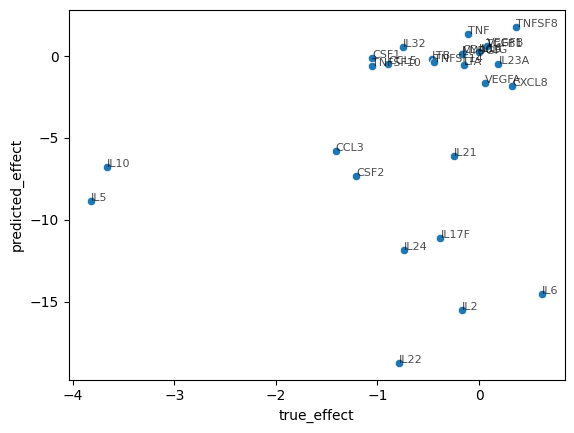

In [56]:
data = all_effects[('GATA3', 'Stim48hr')]

subset = data[data.index.isin(cytokines)].copy()
subset['gene_name'] = subset.index  # annotate index names as new column
ax = sns.scatterplot(
    data=subset,
    x='true_effect', y='predicted_effect'
)
for _, row in subset.iterrows():
    ax.annotate(row['gene_name'], (row['true_effect'], row['predicted_effect']), fontsize=8, alpha=0.7)

In [57]:
tf = 'GATA3'
c = 'Stim8hr'
# Subset data for this target and condition
onetarget = tf_2_gs_effects[
    (tf_2_gs_effects.target_contrast_gene_name == tf) & 
    (tf_2_gs_effects.culture_condition == c)
].drop_duplicates()

# Putative direct hits: sig & has_peak & not self
putative_direct_hits = onetarget[
    (onetarget['gene_name'] != tf) &
    (onetarget['significant']) &
    (onetarget['has_peak'] == 1)
].gene_name.unique().tolist()
putative_direct_effect = onetarget[
    (onetarget['gene_name'] != tf) &
    (onetarget['significant']) &
    (onetarget['has_peak'] == 1)
].set_index('gene_name').log_fc

# Compute indirect effects matrix (n_genes × n_direct_hits)
indirect_effects_long = get_DE_results_long(adata_de, targets=putative_direct_hits)
indirect_effects_long = indirect_effects_long[indirect_effects_long['culture_condition'] == c]
indirect_effects = indirect_effects_long.pivot(index='gene_name', columns='target_contrast_gene_name', values='log_fc')

indirect_effects = _mask_nonsignificant(
    indirect_effects_long, indirect_effects, c, 'log_fc', 0.1
)


In [63]:
indirect_effects_df = get_DE_results_long(adata_de, targets=putative_direct_hits)
indirect_effects_df = indirect_effects_df[indirect_effects_df['culture_condition'] == 'Stim8hr']

In [69]:
indirect_effects_df[indirect_effects_df['gene_name'] == 'IL16'].sort_values("adj_p_value")[0:30]

,index,gene,log_fc,zscore,adj_p_value,significant,gene_name,culture_condition,target_contrast,target_contrast_gene_name
1587395,ENSG00000168610_Stim8hr,IL16,0.923496,6.239991,4.911668e-08,True,IL16,Stim8hr,ENSG00000168610,STAT3
332991,ENSG00000099219_Stim8hr,IL16,-1.115379,-6.191664,2.456312e-06,True,IL16,Stim8hr,ENSG00000099219,ERMP1
240453,ENSG00000074370_Stim8hr,IL16,-0.177897,-1.154869,6.455015e-01,False,IL16,Stim8hr,ENSG00000074370,ATP2A3
147915,ENSG00000067225_Stim8hr,IL16,-0.094614,-0.599848,7.598836e-01,False,IL16,Stim8hr,ENSG00000067225,PKM
24531,ENSG00000006704_Stim8hr,IL16,-0.333686,-1.812545,7.691518e-01,False,IL16,Stim8hr,ENSG00000006704,GTF2IRD1
600323,ENSG00000115839_Stim8hr,IL16,-0.271076,-1.766040,8.175116e-01,False,IL16,Stim8hr,ENSG00000115839,RAB3GAP1
1278935,ENSG00000147162_Stim8hr,IL16,0.150388,0.880281,8.287277e-01,False,IL16,Stim8hr,ENSG00000147162,OGT
1494857,ENSG00000165525_Stim8hr,IL16,-0.098639,-0.613692,8.328797e-01,False,IL16,Stim8hr,ENSG00000165525,NEMF
816245,ENSG00000123136_Stim8hr,IL16,0.194515,0.978439,8.344498e-01,False,IL16,Stim8hr,ENSG00000123136,DDX39A
476939,ENSG00000115020_Stim8hr,IL16,0.298352,1.200294,8.397627e-01,False,IL16,Stim8hr,ENSG00000115020,PIKFYVE


In [70]:
(indirect_effects.loc['IL16'] * -putative_direct_effect).dropna().sort_values()

STAT3    -0.152217
AAGAB     0.000000
NABP1    -0.000000
NEMF     -0.000000
NIBAN1   -0.000000
            ...   
ITGA4    -0.000000
KLC2     -0.000000
LAIR2     0.000000
ZNF792    0.000000
ERMP1     0.327613
Length: 66, dtype: float64

In [77]:
putative_direct_effect.loc['IL13']
indirect_effects.loc['IL5', 'IL13']

-2.347771413770529